**Reasoning**:
The subtask requires creating a single consolidated code cell for all initial setup, including imports, data loading, model loading, and helper function definitions. I will generate this comprehensive code cell and then modify the original cell `nK8Y1kvq0XFI` to indicate that its contents have been moved, as the new cell will contain all necessary initial imports.



In [ ]:
# All necessary imports
import json
import os
import random
import re
import math
from pathlib import Path
from itertools import combinations
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
from scipy.stats import spearmanr, pearsonr

import torch
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.metrics import mean_squared_error
import nltk
from nltk.corpus import wordnet

print("⚙️ Initializing environment: Loading data, model, and defining helper functions...")

# --- Load df_pairs from sts12-sts dataset ---
print("⚙️ Loading `sts12-sts` dataset and preparing instruction pairs...")
dataset = load_dataset('mteb/sts12-sts')
sts_data = dataset['test']
all_pairs_data = []
for i in tqdm(range(len(sts_data)), desc="Processing STS pairs"):
    entry = sts_data[i]
    sentence1 = entry['sentence1']
    sentence2 = entry['sentence2']
    ground_truth_similarity = float(entry['score']) / 5.0
    all_pairs_data.append({
        'sentence1': sentence1,
        'sentence2': sentence2,
        'ground_truth_similarity': ground_truth_similarity
    })
df_pairs = pd.DataFrame(all_pairs_data)
print(f"✅ Created {len(df_pairs)} instruction pairs from `sts12-sts`.")

# --- Load baseline model ---
print("📥 Loading baseline SBERT model...")
baseline_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"✅ Model loaded: all-MiniLM-L6-v2")

# --- Helper functions ---

# Cosine similarity calculation function
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

def compute_sbert_scores(model: SentenceTransformer, df: pd.DataFrame, batch_size: int = 64) -> np.ndarray:
    """Calculates SBERT cosine similarity for all pairs in the DataFrame."""
    s1_list = df['sentence1'].tolist()
    s2_list = df['sentence2'].tolist()
    print(f"  Encoding (batch_size={batch_size})...")
    emb1 = model.encode(s1_list, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
    emb2 = model.encode(s2_list, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
    scores = [cosine_similarity(e1, e2) for e1, e2 in zip(emb1, emb2)]
    return np.array(scores)

def calculate_pearson_correlation(ground_truth, predictions):
    pearson_corr, _ = pearsonr(ground_truth, predictions)
    return pearson_corr

def calculate_spearman_correlation(ground_truth, predictions):
    spearman_corr, _ = spearmanr(ground_truth, predictions)
    return spearman_corr

def calculate_mse(ground_truth, predictions):
    mse = mean_squared_error(ground_truth, predictions)
    return mse

def calculate_rmse(ground_truth, predictions):
    rmse = math.sqrt(mean_squared_error(ground_truth, predictions))
    return rmse

# Helper function to get token embeddings and tokens
def get_token_embeddings_and_tokens(model, sentence):
    tokenizer = model.tokenizer
    hf_model = model._modules['0'].auto_model
    inputs = tokenizer(sentence, return_tensors='pt', truncation=True, max_length=128)
    device = next(hf_model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = hf_model(**inputs)
    token_embeddings = outputs.last_hidden_state.squeeze().detach().cpu().numpy()
    input_ids_list = inputs['input_ids'].squeeze().tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids_list)
    if tokens and tokens[0] == '[CLS]':
        tokens = tokens[1:]
        token_embeddings = token_embeddings[1:]
    if tokens and tokens[-1] == '[SEP]':
        tokens = tokens[:-1]
        token_embeddings = token_embeddings[:-1]
    return tokens, token_embeddings

# Helper function to plot token similarity heatmap
def plot_token_similarity_heatmap(tokens1, tokens2, embeddings1, embeddings2, title):
    similarity_matrix = np.zeros((len(tokens1), len(tokens2)))
    for i, emb1 in enumerate(embeddings1):
        for j, emb2 in enumerate(embeddings2):
            similarity_matrix[i, j] = cosine_similarity(emb1, emb2)
    plt.figure(figsize=(len(tokens2) * 0.8, len(tokens1) * 0.8))
    sns.heatmap(
        similarity_matrix,
        xticklabels=tokens2,
        yticklabels=tokens1,
        cmap='viridis',
        annot=True,
        fmt=".2f",
        linewidths=.5,
        linecolor='lightgray'
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Sentence 2 Tokens', fontsize=12)
    plt.ylabel('Sentence 1 Tokens', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Negation words list and function
negation_words = [
    "no", "not", "n't", "never", "none", "nothing", "nobody", "nowhere",
    "hardly", "scarcely", "barely", # Implied negations
    "without", "lack", "lacks", "lacking", "fail", "fails", "failed", # Other forms
    "don't", "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
    "haven't", "hasn't", "hadn't", "won't", "wouldn't", "can't", "couldn't",
    "shouldn't", "mightn't", "mustn't"
]

def contains_negation(sentence, negation_list):
    """Checks if a sentence contains any word from the negation_list."""
    words = set(sentence.lower().split())
    for neg_word in negation_list:
        if neg_word in words or any(neg_word in word for word in words if "'" in word):
            return True
    return False

# Jaccard similarity for lexical overlap
def jaccard_similarity(sentence1, sentence2):
    """Calculates Jaccard Similarity between two sentences based on word sets."""
    words1 = set(sentence1.lower().split())
    words2 = set(sentence2.lower().split())
    intersection = len(words1.intersection(words2))
    union = len(words1.union(words2))
    if union == 0:
        return 0.0
    return intersection / union

# Number extraction and comparison functions
def extract_numbers(sentence):
    """Extracts all numerical values from a sentence."""
    numbers = re.findall(r'\\d+\\.?\\d*', sentence)
    return sorted([float(n) for n in numbers])

def has_numerical_difference(s1, s2):
    """Checks if two sentences contain numbers that differ."""
    numbers1 = extract_numbers(s1)
    numbers2 = extract_numbers(s2)
    if numbers1 and numbers2:
        return set(numbers1) != set(numbers2)
    elif (numbers1 and not numbers2) or (not numbers1 and numbers2):
        return True
    return False

def has_numerical_value_discrepancy(s1, s2):
    """Checks if both sentences contain numerical values AND those values are different."""
    numbers1 = extract_numbers(s1)
    numbers2 = extract_numbers(s2)
    if numbers1 and numbers2 and (set(numbers1) != set(numbers2)):
        return True
    return False

def has_numerical_presence_absence_difference(s1, s2):
    """Checks if one sentence contains numerical values and the other does not."""
    numbers1 = extract_numbers(s1)
    numbers2 = extract_numbers(s2)
    if (numbers1 and not numbers2) or (not numbers1 and numbers2):
        return True
    return False

# NLTK downloads and synonymy function
# Download WordNet and Punkt if not already downloaded
try:
    wordnet.synsets('test')
except LookupError:
    print("Downloading 'wordnet' from NLTK...")
    nltk.download('wordnet')
    nltk.download('omw-1.4') # Open Multilingual Wordnet (required for some functions)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading 'punkt' from NLTK...")
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    print("Downloading 'punkt_tab' from NLTK...")
    nltk.download('punkt_tab')

def has_synonymy(sentence1, sentence2):
    """Checks if any word in sentence1 has a synonym in sentence2 (or vice versa) using WordNet."""
    words1 = set(word.lower() for word in nltk.word_tokenize(sentence1) if word.isalpha())
    words2 = set(word.lower() for word in nltk.word_tokenize(sentence2) if word.isalpha())
    if words1.intersection(words2):
        return True
    for word1 in words1:
        for syn in wordnet.synsets(word1):
            for lemma in syn.lemmas():
                if lemma.name().lower() in words2:
                    return True
    return False

# --- Initial computations and challenge set creation ---
print("\n⚙️ Calculating baseline SBERT scores...")
df_pairs['sbert_baseline'] = compute_sbert_scores(baseline_model, df_pairs)
print(f"✅ SBERT scores calculated.")

print("\n⚙️ Classifying sentence pairs for linguistic phenomena...")
# Negation
df_pairs['has_negation'] = df_pairs.apply(
    lambda row: contains_negation(row['sentence1'], negation_words) or \
                contains_negation(row['sentence2'], negation_words),
    axis=1
)
negation_pairs = df_pairs[df_pairs['has_negation']].copy()
print(f"   Found {len(negation_pairs)} pairs containing negation.")

# High Lexical Overlap
LEXICAL_OVERLAP_THRESHOLD = 0.5
df_pairs['has_high_lexical_overlap'] = df_pairs.apply(
    lambda row: jaccard_similarity(row['sentence1'], row['sentence2']) >= LEXICAL_OVERLAP_THRESHOLD,
    axis=1
)
high_lexical_overlap_pairs = df_pairs[df_pairs['has_high_lexical_overlap']].copy()
print(f"   Found {len(high_lexical_overlap_pairs)} pairs containing high lexical overlap (Jaccard >= {LEXICAL_OVERLAP_THRESHOLD}).")

# Numerical Differences (General)
df_pairs['has_numerical_difference'] = df_pairs.apply(
    lambda row: has_numerical_difference(row['sentence1'], row['sentence2']),
    axis=1
)
numerical_difference_pairs = df_pairs[df_pairs['has_numerical_difference']].copy()
print(f"   Found {len(numerical_difference_pairs)} pairs containing numerical changes/differences (general).")

# Numerical Value Discrepancy
df_pairs['has_numerical_value_discrepancy'] = df_pairs.apply(
    lambda row: has_numerical_value_discrepancy(row['sentence1'], row['sentence2']),
    axis=1
)
numerical_value_discrepancy_pairs = df_pairs[df_pairs['has_numerical_value_discrepancy']].copy()
print(f"   Found {len(numerical_value_discrepancy_pairs)} pairs with numerical value discrepancies.")

# Numerical Presence/Absence Difference
df_pairs['has_numerical_presence_absence_difference'] = df_pairs.apply(
    lambda row: has_numerical_presence_absence_difference(row['sentence1'], row['sentence2']),
    axis=1
)
numerical_presence_absence_pairs = df_pairs[df_pairs['has_numerical_presence_absence_difference']].copy()
print(f"   Found {len(numerical_presence_absence_pairs)} pairs with numerical presence/absence differences.")

# Synonymy (Not directly used as a challenge set but classified)
df_pairs['has_synonymy'] = df_pairs.apply(
    lambda row: has_synonymy(row['sentence1'], row['sentence2']),
    axis=1
)
synonymy_pairs = df_pairs[df_pairs['has_synonymy']].copy()
print(f"   Found {len(synonymy_pairs)} pairs containing synonymy.")


# Normal Control Pairs
normal_control_pairs = df_pairs[
    (~df_pairs['has_negation']) &
    (~df_pairs['has_numerical_value_discrepancy']) &
    (~df_pairs['has_numerical_presence_absence_difference'])
].copy()
print(f"   Created {len(normal_control_pairs)} normal control pairs (no negation, no specific numerical differences).")

print("✅ Environment initialization complete.")

⚙️ Initializing environment: Loading data, model, and defining helper functions...
⚙️ Loading `sts12-sts` dataset and preparing instruction pairs...


Processing STS pairs:   0%|          | 0/3108 [00:00<?, ?it/s]

✅ Created 3108 instruction pairs from `sts12-sts`.
📥 Loading baseline SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded: all-MiniLM-L6-v2

⚙️ Calculating baseline SBERT scores...
  Encoding (batch_size=64)...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Batches:   0%|          | 0/49 [00:00<?, ?it/s]

✅ SBERT scores calculated.

⚙️ Classifying sentence pairs for linguistic phenomena...
   Found 255 pairs containing negation.
   Found 1356 pairs containing high lexical overlap (Jaccard >= 0.5).
   Found 0 pairs containing numerical changes/differences (general).
   Found 0 pairs with numerical value discrepancies.
   Found 0 pairs with numerical presence/absence differences.
   Found 3100 pairs containing synonymy.
   Created 2853 normal control pairs (no negation, no specific numerical differences).
✅ Environment initialization complete.


## Section: Data Preparation for SBERT Analysis - Using `sts12-sts` Dataset

This section now prepares the dataset by loading the `sts12-sts` dataset from Hugging Face. It directly uses the provided sentence pairs and their gold-standard similarity scores as the basis for `df_pairs`.

In [ ]:
from datasets import load_dataset

print("⚙️ Loading `sts12-sts` dataset and preparing instruction pairs...")

# Load the dataset
dataset = load_dataset('mteb/sts12-sts')

# For simplicity, let's use the 'test' split to create our df_pairs directly.
sts_data = dataset['test']

all_pairs_data = []

for i in tqdm(range(len(sts_data)), desc="Processing STS pairs"):
    entry = sts_data[i]
    sentence1 = entry['sentence1']
    sentence2 = entry['sentence2']
    # Re-introduce ground truth similarity score
    # Normalize similarity score to range [0, 1] if it's originally [0, 5]
    # The sts12-sts dataset has scores typically from 0 to 5, so we divide by 5.0
    ground_truth_similarity = float(entry['score']) / 5.0 # Changed 'similarity' to 'score'

    all_pairs_data.append({
        'sentence1': sentence1,
        'sentence2': sentence2,
        'ground_truth_similarity': ground_truth_similarity
    })

df_pairs = pd.DataFrame(all_pairs_data)

print(f"✅ Created {len(df_pairs)} instruction pairs from `sts12-sts`.")
print("First 5 rows of df_pairs:")
display(df_pairs.head())

⚙️ Loading `sts12-sts` dataset and preparing instruction pairs...


Processing STS pairs:   0%|          | 0/3108 [00:00<?, ?it/s]

✅ Created 3108 instruction pairs from `sts12-sts`.
First 5 rows of df_pairs:


,sentence1,sentence2,ground_truth_similarity
0,the problem likely will mean corrective change...,he said the problem needs to be corrected befo...,0.88
1,the technology-laced nasdaq composite index .i...,the broad standard & poor 's 500 index .spx in...,0.16
2,""" it 's a huge black eye , "" said publisher ar...",""" it 's a huge black eye , "" arthur sulzberger...",0.72
3,sec chairman william donaldson said there is a...,""" i think there 's a building confidence that ...",0.68
4,vivendi shares closed 1.9 percent at 15.80 eur...,"in new york , vivendi shares were 1.4 percent ...",0.28


### Dataset Structure Overview

Let's examine the structure of the `df_pairs` DataFrame, including column data types, non-null values, and descriptive statistics.

In [ ]:
print("\n--- DataFrame Information ---")
df_pairs.info()

print("\n--- Descriptive Statistics ---")
display(df_pairs.describe())


--- DataFrame Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3108 entries, 0 to 3107
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   sentence1                3108 non-null   object 
 1   sentence2                3108 non-null   object 
 2   ground_truth_similarity  3108 non-null   float64
dtypes: float64(1), object(2)
memory usage: 73.0+ KB

--- Descriptive Statistics ---


,ground_truth_similarity
count,3108.000000
mean,0.701213
std,0.274125
min,0.000000
25%,0.561800
50%,0.760000
75%,0.920000
max,1.000000


📊 Ground Truth Similarity Score Distribution Analysis
   Ground Truth similarity statistics (all pairs):
count    3108.000000
mean        0.701213
std         0.274125
min         0.000000
25%         0.561800
50%         0.760000
75%         0.920000
max         1.000000


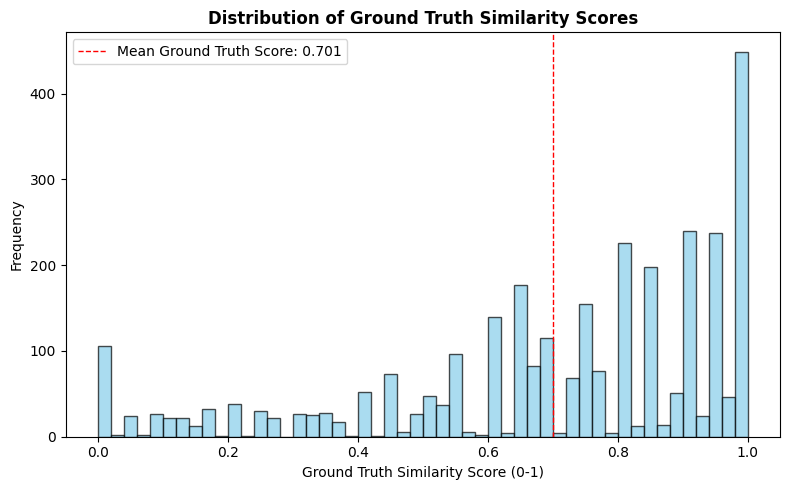


Interpretation: This histogram shows the distribution of human-annotated ground truth similarity scores. Comparing this to the SBERT score distribution can highlight differences in how human evaluators and the model perceive similarity.


In [ ]:
print("📊 Ground Truth Similarity Score Distribution Analysis")
print("=" * 50)
print(f"   Ground Truth similarity statistics (all pairs):")
print(df_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_pairs['ground_truth_similarity'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(df_pairs['ground_truth_similarity'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {df_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation: This histogram shows the distribution of human-annotated ground truth similarity scores. Comparing this to the SBERT score distribution can highlight differences in how human evaluators and the model perceive similarity.")

## Section : Baseline SBERT Score Calculation

### Splitting Data into Training, Validation, and Test Sets

Now, the generated `df_pairs` DataFrame is split into training, validation, and test sets. A common split ratio is used (e.g., 80% for training, 10% for validation, and 10% for testing) to ensure robust model evaluation.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd # Ensure pandas is imported as 'pd'

print("⚙️ Splitting data into training, validation, and test sets with stratification...")

# Ensure reproducibility
np.random.seed(42)
random.seed(42)

# Create 'similarity_bin' for stratification
# 1. Define the bin edges
bin_edges = np.linspace(0, 1, 11)

# 2. Discretize the 'ground_truth_similarity' into these bins
# Create labels for the bins (e.g., '0.0-0.1', '0.1-0.2', ...)
bin_labels = [f'{edge:.1f}-{(edge+0.1):.1f}' for edge in bin_edges[:-1]]

df_pairs['similarity_bin'] = pd.cut(df_pairs['ground_truth_similarity'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# First split: 80% train, 20% for temp (val + test)
df_train, df_temp = train_test_split(
    df_pairs,
    test_size=0.2,
    random_state=42,
    stratify=df_pairs['similarity_bin']
)

# Second split: 10% val, 10% test from df_temp (0.5 of df_temp is 10% of total)
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5, # This makes val_size = 0.1 and test_size = 0.1 of original total
    random_state=42,
    stratify=df_temp['similarity_bin']
)

print(f"✅ Data split complete with stratification:")
print(f"   Training set size: {len(df_train)} samples")
print(f"   Validation set size: {len(df_val)} samples")
print(f"   Test set size: {len(df_test)} samples")

print("\nFirst 5 rows of training set:")
display(df_train.head())

⚙️ Splitting data into training, validation, and test sets with stratification...
✅ Data split complete with stratification:
   Training set size: 2486 samples
   Validation set size: 311 samples
   Test set size: 311 samples

First 5 rows of training set:


,sentence1,sentence2,ground_truth_similarity,similarity_bin
2434,beat or pound rapidly,cause to throb or beat rapidly .,0.80,0.7-0.8
580,the 30-year bond us30yt = rr rose 22 / 32 for ...,the 30-year bond us30yt = rr grew 1-3 / 32 for...,0.76,0.7-0.8
624,"a second victim , michael walker , 23 , was st...","the other victim , michael walker , of 550 bar...",0.44,0.4-0.5
581,the institute for supply management 's index o...,the institute for supply management said its i...,0.68,0.6-0.7
1719,there must be a balance as a whole .,the unit must be in balance .,0.95,0.9-1.0


In [ ]:
# ── Load baseline model ────────────────────────────────────────
print("📥 Loading baseline SBERT model...")
baseline_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"✅ Model loaded: all-MiniLM-L6-v2")

# Cosine similarity calculation function
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-10))

def compute_sbert_scores(model: SentenceTransformer, df: pd.DataFrame, batch_size: int = 64) -> np.ndarray:
    """Calculates SBERT cosine similarity for all pairs in the DataFrame"""
    s1_list = df['sentence1'].tolist()
    s2_list = df['sentence2'].tolist()

    print(f"  Encoding (batch_size={batch_size})...")
    emb1 = model.encode(s1_list, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
    emb2 = model.encode(s2_list, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)

    # Calculate cosine similarity in batches
    scores = [cosine_similarity(e1, e2) for e1, e2 in zip(emb1, emb2)]
    return np.array(scores)

print("\n⚙️  Calculating baseline SBERT scores...")
df_pairs['sbert_baseline'] = compute_sbert_scores(baseline_model, df_pairs)

print(f"\n✅ Calculation complete")
print(f"   SBERT score statistics:")
print(df_pairs['sbert_baseline'].describe().to_string())

📥 Loading baseline SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded: all-MiniLM-L6-v2

⚙️  Calculating baseline SBERT scores...
  Encoding (batch_size=64)...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]

Batches:   0%|          | 0/49 [00:00<?, ?it/s]


✅ Calculation complete
   SBERT score statistics:
count    3108.000000
mean        0.701985
std         0.235337
min        -0.166267
25%         0.596428
50%         0.762694
75%         0.874469
max         1.000000


📊 SBERT Score Distribution Analysis
   SBERT score statistics (all pairs):
count    3108.000000
mean        0.701985
std         0.235337
min        -0.166267
25%         0.596428
50%         0.762694
75%         0.874469
max         1.000000


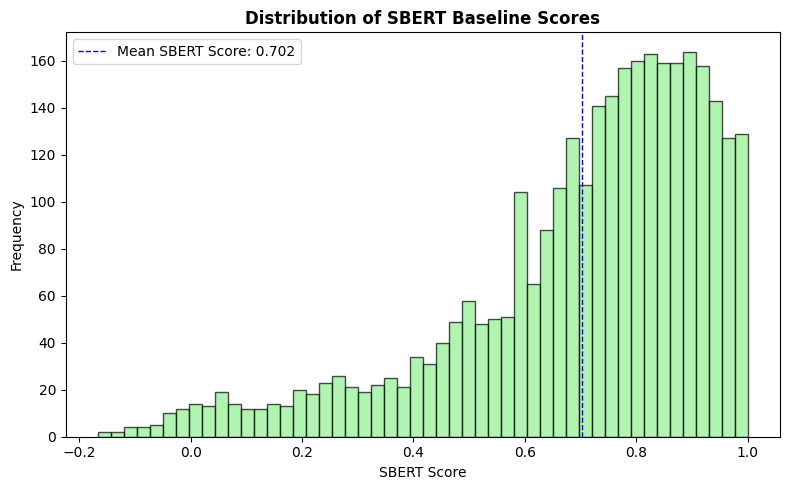


Interpretation: This histogram shows the distribution of SBERT cosine similarity scores across all sentence pairs. 
A wider distribution indicates a range of similarities detected by the model.


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 4-1: SBERT Score Distribution Analysis
# ══════════════════════════════════════════════════════════════════════

print("📊 SBERT Score Distribution Analysis")
print("=" * 50)
print(f"   SBERT score statistics (all pairs):")
print(df_pairs['sbert_baseline'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_pairs['sbert_baseline'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(df_pairs['sbert_baseline'].mean(), color='blue', linestyle='--', linewidth=1, label=f'Mean SBERT Score: {df_pairs["sbert_baseline"].mean():.3f}')
ax.set_title('Distribution of SBERT Baseline Scores', fontweight='bold')
ax.set_xlabel('SBERT Score')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation: This histogram shows the distribution of SBERT cosine similarity scores across all sentence pairs. ")
print("A wider distribution indicates a range of similarities detected by the model.")

## Section: Performance Benchmark - Quantitative Evaluation

This section establishes the baseline model's performance using standard evaluation metrics: Pearson Correlation Coefficient, Spearman Rank Correlation Coefficient, and Mean Squared Error (MSE). These metrics provide a quantitative measure of how well the SBERT model's similarity predictions align with the human-annotated ground truth similarities from the STS-B dataset.

In [ ]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

# Define functions for evaluation metrics
def calculate_pearson_correlation(ground_truth, predictions):
    pearson_corr, _ = pearsonr(ground_truth, predictions)
    return pearson_corr

def calculate_spearman_correlation(ground_truth, predictions):
    spearman_corr, _ = spearmanr(ground_truth, predictions)
    return spearman_corr

def calculate_mse(ground_truth, predictions):
    mse = mean_squared_error(ground_truth, predictions)
    return mse

def calculate_rmse(ground_truth, predictions):
    rmse = math.sqrt(mean_squared_error(ground_truth, predictions))
    return rmse

print("⚙️ Calculating Pearson and Spearman correlation coefficients and MSE...")

# Extract the SBERT baseline scores and ground truth similarity scores
sbert_scores = df_pairs['sbert_baseline'].values
ground_truth_scores = df_pairs['ground_truth_similarity'].values

# 1. Pearson Correlation Coefficient
pearson_corr = calculate_pearson_correlation(ground_truth_scores, sbert_scores)
print(f"\n✅ Pearson Correlation Coefficient: {pearson_corr:.4f}")

# 2. Spearman Rank Correlation Coefficient
spearman_corr = calculate_spearman_correlation(ground_truth_scores, sbert_scores)
print(f"✅ Spearman Rank Correlation Coefficient: {spearman_corr:.4f}")

# 3. Mean Squared Error (MSE)
mse = calculate_mse(ground_truth_scores, sbert_scores)
print(f"✅ Mean Squared Error (MSE): {mse:.4f}")

# Optionally, calculate RMSE (Root Mean Squared Error) for better interpretability
rmse = calculate_rmse(ground_truth_scores, sbert_scores)
print(f"   Root Mean Squared Error (RMSE): {rmse:.4f}")

print("\nInterpretation: These metrics quantify the agreement between the SBERT model's predictions and the human-annotated ground truth. Higher correlation values (closer to 1) and lower MSE indicate better model performance.")

⚙️ Calculating Pearson and Spearman correlation coefficients and MSE...

✅ Pearson Correlation Coefficient: 0.8136
✅ Spearman Rank Correlation Coefficient: 0.7237
✅ Mean Squared Error (MSE): 0.0255
   Root Mean Squared Error (RMSE): 0.1598

Interpretation: These metrics quantify the agreement between the SBERT model's predictions and the human-annotated ground truth. Higher correlation values (closer to 1) and lower MSE indicate better model performance.


### Visualizing the Relationship between SBERT Scores and Ground Truth

A scatter plot can visually represent the correlation between the SBERT model's predicted similarity scores and the human-annotated ground truth scores.

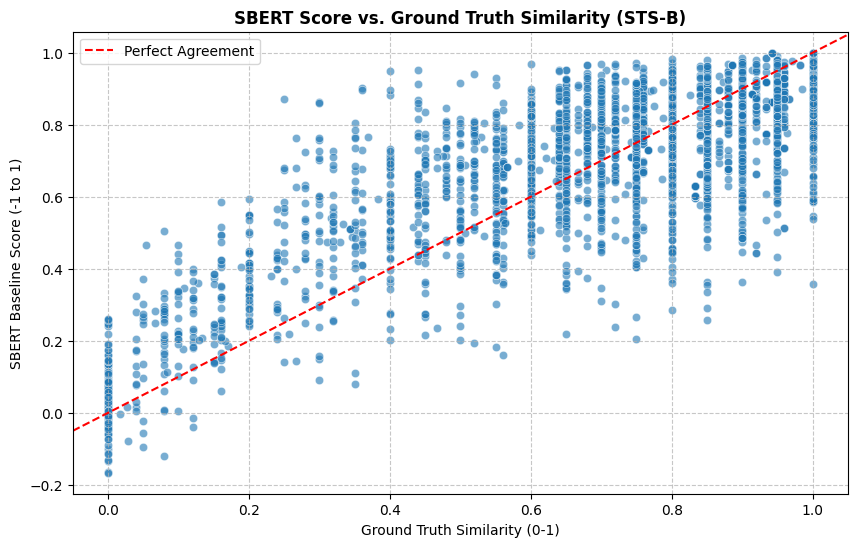

Interpretation: The scatter plot visually demonstrates the relationship between the SBERT scores and the ground truth. Points clustered around the red 'Perfect Agreement' line indicate good alignment, while deviations suggest discrepancies.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=ground_truth_scores, y=sbert_scores, alpha=0.6)
plt.title('SBERT Score vs. Ground Truth Similarity (STS-B)', fontweight='bold')
plt.xlabel('Ground Truth Similarity (0-1)')
plt.ylabel('SBERT Baseline Score (-1 to 1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='Perfect Agreement')
plt.legend()
plt.show()

print("Interpretation: The scatter plot visually demonstrates the relationship between the SBERT scores and the ground truth. Points clustered around the red 'Perfect Agreement' line indicate good alignment, while deviations suggest discrepancies.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoTokenizer

# Helper function to get token embeddings and tokens
def get_token_embeddings_and_tokens(model, sentence):
    # Access the tokenizer directly from the SentenceTransformer model instance
    tokenizer = model.tokenizer

    # Get the underlying Hugging Face transformer model
    # This assumes the first module (index 0) in the SentenceTransformer is the Transformer model.
    # The actual Hugging Face model (e.g., BertModel) is then accessed via .auto_model
    hf_model = model._modules['0'].auto_model

    inputs = tokenizer(sentence, return_tensors='pt', truncation=True, max_length=128)

    # Ensure inputs are on the same device as the model
    device = next(hf_model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Call the Hugging Face model directly
    with torch.no_grad(): # Disable gradient calculation for inference
        outputs = hf_model(**inputs)

    token_embeddings = outputs.last_hidden_state.squeeze().detach().cpu().numpy()
    input_ids_list = inputs['input_ids'].squeeze().tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids_list)

    # Remove CLS and SEP tokens if present for cleaner visualization of actual words
    if tokens and tokens[0] == '[CLS]':
        tokens = tokens[1:]
        token_embeddings = token_embeddings[1:]
    if tokens and tokens[-1] == '[SEP]':
        tokens = tokens[:-1]
        token_embeddings = token_embeddings[:-1]

    return tokens, token_embeddings

# Helper function to plot token similarity heatmap
def plot_token_similarity_heatmap(tokens1, tokens2, embeddings1, embeddings2, title):
    # Calculate cosine similarity matrix
    similarity_matrix = np.zeros((len(tokens1), len(tokens2)))
    for i, emb1 in enumerate(embeddings1):
        for j, emb2 in enumerate(embeddings2):
            similarity_matrix[i, j] = cosine_similarity(emb1, emb2)

    plt.figure(figsize=(len(tokens2) * 0.8, len(tokens1) * 0.8))
    sns.heatmap(
        similarity_matrix,
        xticklabels=tokens2,
        yticklabels=tokens1,
        cmap='viridis',
        annot=True,
        fmt=".2f",
        linewidths=.5,
        linecolor='lightgray'
    )
    plt.title(title, fontsize=14)
    plt.xlabel('Sentence 2 Tokens', fontsize=12)
    plt.ylabel('Sentence 1 Tokens', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

### Example 1: High Ground Truth Similarity Pair

Let's pick a pair with high ground truth similarity and visualize the token-level similarities.

Sentence 1: the vote will take place today at 5.30 p.m .
Sentence 2: the vote will take place at 17h30 .
Ground Truth Similarity: 1.00
SBERT Baseline Score: 0.84


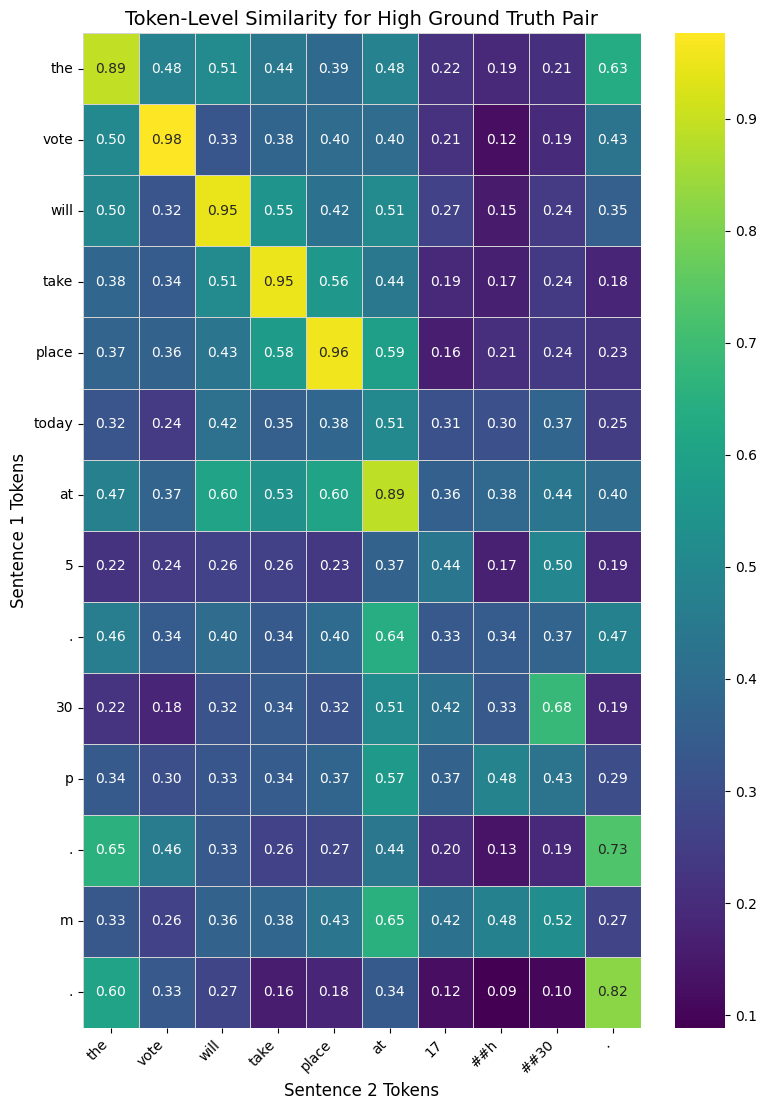

In [ ]:
# Select a high similarity pair (e.g., top 1 by ground_truth_similarity)
high_sim_pair = df_pairs.sort_values(by='ground_truth_similarity', ascending=False).iloc[0]

sentence1_high = high_sim_pair['sentence1']
sentence2_high = high_sim_pair['sentence2']

print(f"Sentence 1: {sentence1_high}")
print(f"Sentence 2: {sentence2_high}")
print(f"Ground Truth Similarity: {high_sim_pair['ground_truth_similarity']:.2f}")
print(f"SBERT Baseline Score: {high_sim_pair['sbert_baseline']:.2f}")

# Get token embeddings
tokens1_high, embeddings1_high = get_token_embeddings_and_tokens(baseline_model, sentence1_high)
tokens2_high, embeddings2_high = get_token_embeddings_and_tokens(baseline_model, sentence2_high)

# Plot heatmap
plot_token_similarity_heatmap(
    tokens1_high, tokens2_high, embeddings1_high, embeddings2_high,
    'Token-Level Similarity for High Ground Truth Pair'
)

### Example 2: Low Ground Truth Similarity Pair

Now, let's look at a pair with low ground truth similarity.

Sentence 1: a young man is playing the piano .
Sentence 2: a woman is peeling a prawn .
Ground Truth Similarity: 0.00
SBERT Baseline Score: -0.04


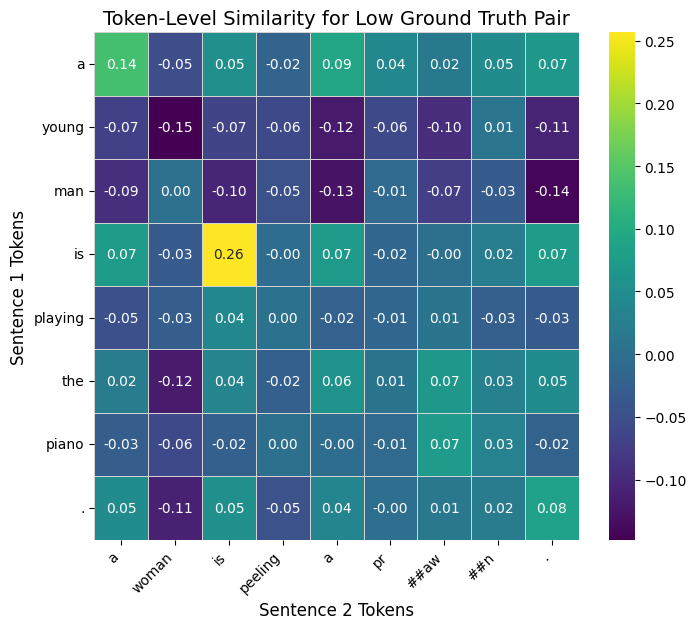

In [ ]:
# Select a low similarity pair (e.g., top 1 by ground_truth_similarity)
low_sim_pair = df_pairs.sort_values(by='ground_truth_similarity', ascending=True).iloc[0]

sentence1_low = low_sim_pair['sentence1']
sentence2_low = low_sim_pair['sentence2']

print(f"Sentence 1: {sentence1_low}")
print(f"Sentence 2: {sentence2_low}")
print(f"Ground Truth Similarity: {low_sim_pair['ground_truth_similarity']:.2f}")
print(f"SBERT Baseline Score: {low_sim_pair['sbert_baseline']:.2f}")

# Get token embeddings
tokens1_low, embeddings1_low = get_token_embeddings_and_tokens(baseline_model, sentence1_low)
tokens2_low, embeddings2_low = get_token_embeddings_and_tokens(baseline_model, sentence2_low)

# Plot heatmap
plot_token_similarity_heatmap(
    tokens1_low, tokens2_low, embeddings1_low, embeddings2_low,
    'Token-Level Similarity for Low Ground Truth Pair'
)

### Example 3: High Error Case (Discrepancy between SBERT and Ground Truth)

We will now identify and visualize a case where the SBERT score significantly deviates from the ground truth similarity.

Sentence 1: a written message of nonacceptance
Sentence 2: a message refusing to accept something that is offered .
Ground Truth Similarity: 1.00
SBERT Baseline Score: 0.36
Absolute Error: 0.64


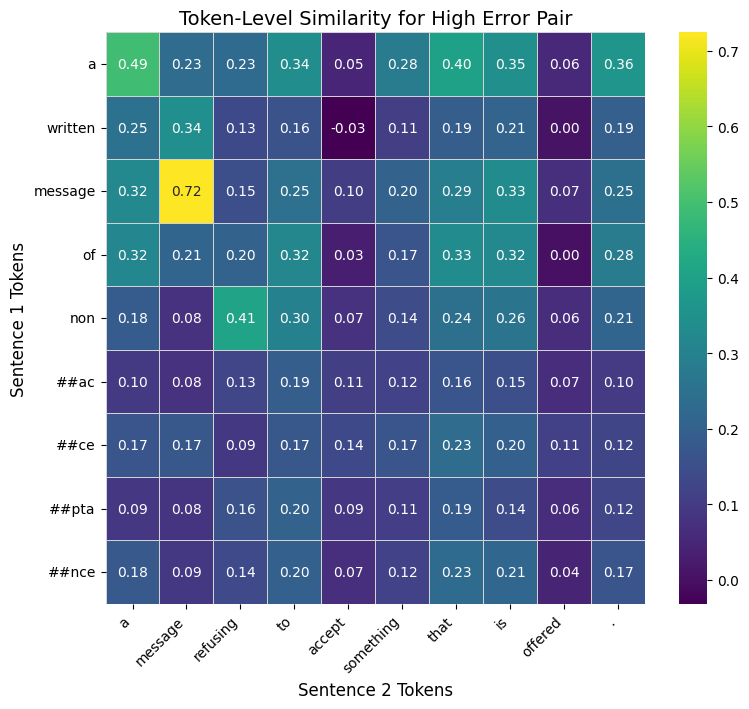

In [ ]:
# Calculate the absolute error between SBERT and ground truth
df_pairs['error'] = abs(df_pairs['sbert_baseline'] - df_pairs['ground_truth_similarity'])

# Select the pair with the highest error
high_error_pair = df_pairs.sort_values(by='error', ascending=False).iloc[0]

sentence1_error = high_error_pair['sentence1']
sentence2_error = high_error_pair['sentence2']

print(f"Sentence 1: {sentence1_error}")
print(f"Sentence 2: {sentence2_error}")
print(f"Ground Truth Similarity: {high_error_pair['ground_truth_similarity']:.2f}")
print(f"SBERT Baseline Score: {high_error_pair['sbert_baseline']:.2f}")
print(f"Absolute Error: {high_error_pair['error']:.2f}")

# Get token embeddings
tokens1_error, embeddings1_error = get_token_embeddings_and_tokens(baseline_model, sentence1_error)
tokens2_error, embeddings2_error = get_token_embeddings_and_tokens(baseline_model, sentence2_error)

# Plot heatmap
plot_token_similarity_heatmap(
    tokens1_error, tokens2_error, embeddings1_error, embeddings2_error,
    'Token-Level Similarity for High Error Pair'
)

## Section 6: Linguistic Phenomenon Evaluation

To evaluate the model's performance on specific linguistic phenomena (e.g., synonymy, negation, numerical changes, high lexical overlap), we would typically need a dataset where sentence pairs are explicitly labeled or categorized by these phenomena. The `sts12-sts` dataset primarily provides similarity scores without fine-grained linguistic annotations.

**Next Steps for this section:**

To proceed with a 'Linguistic Phenomenon Evaluation', please provide guidance on one of the following approaches:

1.  **Manual Annotation:** If a small subset of data can be manually annotated for these linguistic features.
2.  **External Dataset:** If there's another dataset available that is pre-annotated for these linguistic phenomena.
3.  **Rule-based Classification:** If specific rules or heuristics can be defined to automatically categorize the existing `sts12-sts` pairs (e.g., checking for negation words, number comparisons, etc.).

Once we have a method for categorizing pairs, we can then evaluate the SBERT model's performance (e.g., average similarity, correlation) within each linguistic category.

This reasoning text is now redundant. The functionality it described (confirming `negation_pairs` by re-initializing it) has been moved to the consolidated setup cell (cell `02e36157`).

### Evaluating SBERT Performance on Negation Pairs

In [ ]:
print("⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for negation pairs...")

# Extract the SBERT baseline scores and ground truth similarity scores for negation pairs
sbert_scores_negation = negation_pairs['sbert_baseline'].values
ground_truth_scores_negation = negation_pairs['ground_truth_similarity'].values

# 1. Pearson Correlation Coefficient
pearson_corr_negation = calculate_pearson_correlation(ground_truth_scores_negation, sbert_scores_negation)
print(f"\n✅ Pearson Correlation Coefficient (Negation Pairs): {pearson_corr_negation:.4f}")

# 2. Spearman Rank Correlation Coefficient
spearman_corr_negation = calculate_spearman_correlation(ground_truth_scores_negation, sbert_scores_negation)
print(f"✅ Spearman Rank Correlation Coefficient (Negation Pairs): {spearman_corr_negation:.4f}")

# 3. Mean Squared Error (MSE)
mse_negation = calculate_mse(ground_truth_scores_negation, sbert_scores_negation)
print(f"✅ Mean Squared Error (MSE) (Negation Pairs): {mse_negation:.4f}")

# 4. Root Mean Squared Error (RMSE)
rmse_negation = calculate_rmse(ground_truth_scores_negation, sbert_scores_negation)
print(f"   Root Mean Squared Error (RMSE) (Negation Pairs): {rmse_negation:.4f}")

print("\nInterpretation: Compare these metrics to the overall performance metrics to see how negation impacts the SBERT model's accuracy and ranking ability. Significant differences might indicate that negation is a challenging phenomenon for the model.")

⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for negation pairs...

✅ Pearson Correlation Coefficient (Negation Pairs): 0.6533
✅ Spearman Rank Correlation Coefficient (Negation Pairs): 0.6343
✅ Mean Squared Error (MSE) (Negation Pairs): 0.0214
   Root Mean Squared Error (RMSE) (Negation Pairs): 0.1461

Interpretation: Compare these metrics to the overall performance metrics to see how negation impacts the SBERT model's accuracy and ranking ability. Significant differences might indicate that negation is a challenging phenomenon for the model.


### Qualitative Analysis: Negation Challenges

Let's examine specific examples from the `negation_pairs` where SBERT's score is high, but the ground truth similarity is low, suggesting the model failed to properly account for the negation.

In [ ]:
# Calculate the difference between SBERT and ground truth for negation pairs
# To avoid SettingWithCopyWarning, explicitly create a copy if modifying a subset
negation_pairs_copy = negation_pairs.copy()
negation_pairs_copy['sbert_gt_diff'] = negation_pairs_copy['sbert_baseline'] - negation_pairs_copy['ground_truth_similarity']

# Sort by this difference in descending order to find cases where SBERT is much higher than GT
high_sbert_low_gt_negation = negation_pairs_copy.sort_values(by='sbert_gt_diff', ascending=False)

print(f"Found {len(high_sbert_low_gt_negation)} negation pairs.")
print("Top 5 negation pairs where SBERT score is much higher than ground truth:")
display(high_sbert_low_gt_negation[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline', 'sbert_gt_diff']].head())

Found 255 negation pairs.
Top 5 negation pairs where SBERT score is much higher than ground truth:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline,sbert_gt_diff
267,lawtey is not the first faith-based program in...,but lawtey is the first entire prison to take ...,0.25,0.675135,0.425135
677,"as a result , murphy sought to substitute stri...","murphy said strier 's sister , ethel celnik , ...",0.35,0.762900,0.412900
712,"the woman was hospitalized june 15 , kansas he...",missouri health officials said he had not been...,0.20,0.594413,0.394413
2845,being a muslim and being an islamist are not t...,it is necessary to are two different things .,0.05,0.371883,0.321883
55,but it is clear that the joint intelligence co...,this report was cleared by the joint intellige...,0.40,0.711119,0.311119


#### Example 1: High SBERT, Low Ground Truth - Negation Case

Sentence 1: lawtey is not the first faith-based program in florida 's prison system .
Sentence 2: but lawtey is the first entire prison to take that path .
Ground Truth Similarity: 0.25
SBERT Baseline Score: 0.68
Difference (SBERT - GT): 0.43


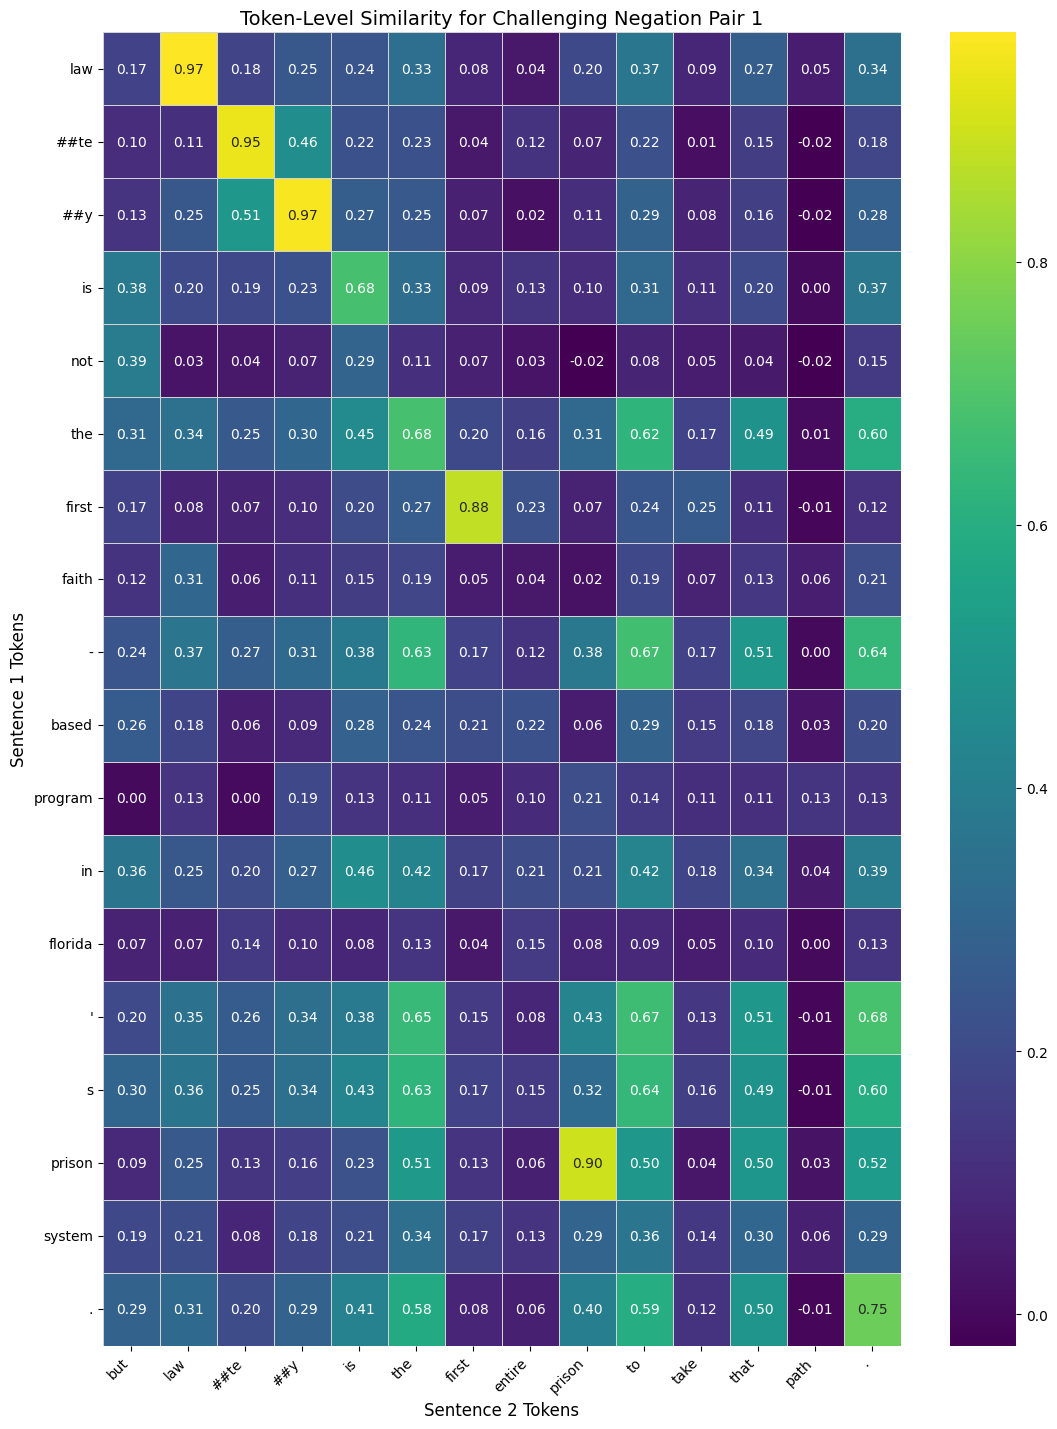

In [ ]:
# Select the top example
challenging_negation_pair = high_sbert_low_gt_negation.iloc[0]

sentence1_neg = challenging_negation_pair['sentence1']
sentence2_neg = challenging_negation_pair['sentence2']

print(f"Sentence 1: {sentence1_neg}")
print(f"Sentence 2: {sentence2_neg}")
print(f"Ground Truth Similarity: {challenging_negation_pair['ground_truth_similarity']:.2f}")
print(f"SBERT Baseline Score: {challenging_negation_pair['sbert_baseline']:.2f}")
print(f"Difference (SBERT - GT): {challenging_negation_pair['sbert_gt_diff']:.2f}")

# Get token embeddings
tokens1_neg, embeddings1_neg = get_token_embeddings_and_tokens(baseline_model, sentence1_neg)
tokens2_neg, embeddings2_neg = get_token_embeddings_and_tokens(baseline_model, sentence2_neg)

# Plot heatmap
plot_token_similarity_heatmap(
    tokens1_neg, tokens2_neg, embeddings1_neg, embeddings2_neg,
    'Token-Level Similarity for Challenging Negation Pair 1'
)

#### Example 2: Another High SBERT, Low Ground Truth - Negation Case

Sentence 1: as a result , murphy sought to substitute strier 's sister , ethel celnik , as the trustee .
Sentence 2: murphy said strier 's sister , ethel celnik , was in the courtroom at the time , but strier was not .
Ground Truth Similarity: 0.35
SBERT Baseline Score: 0.76
Difference (SBERT - GT): 0.41


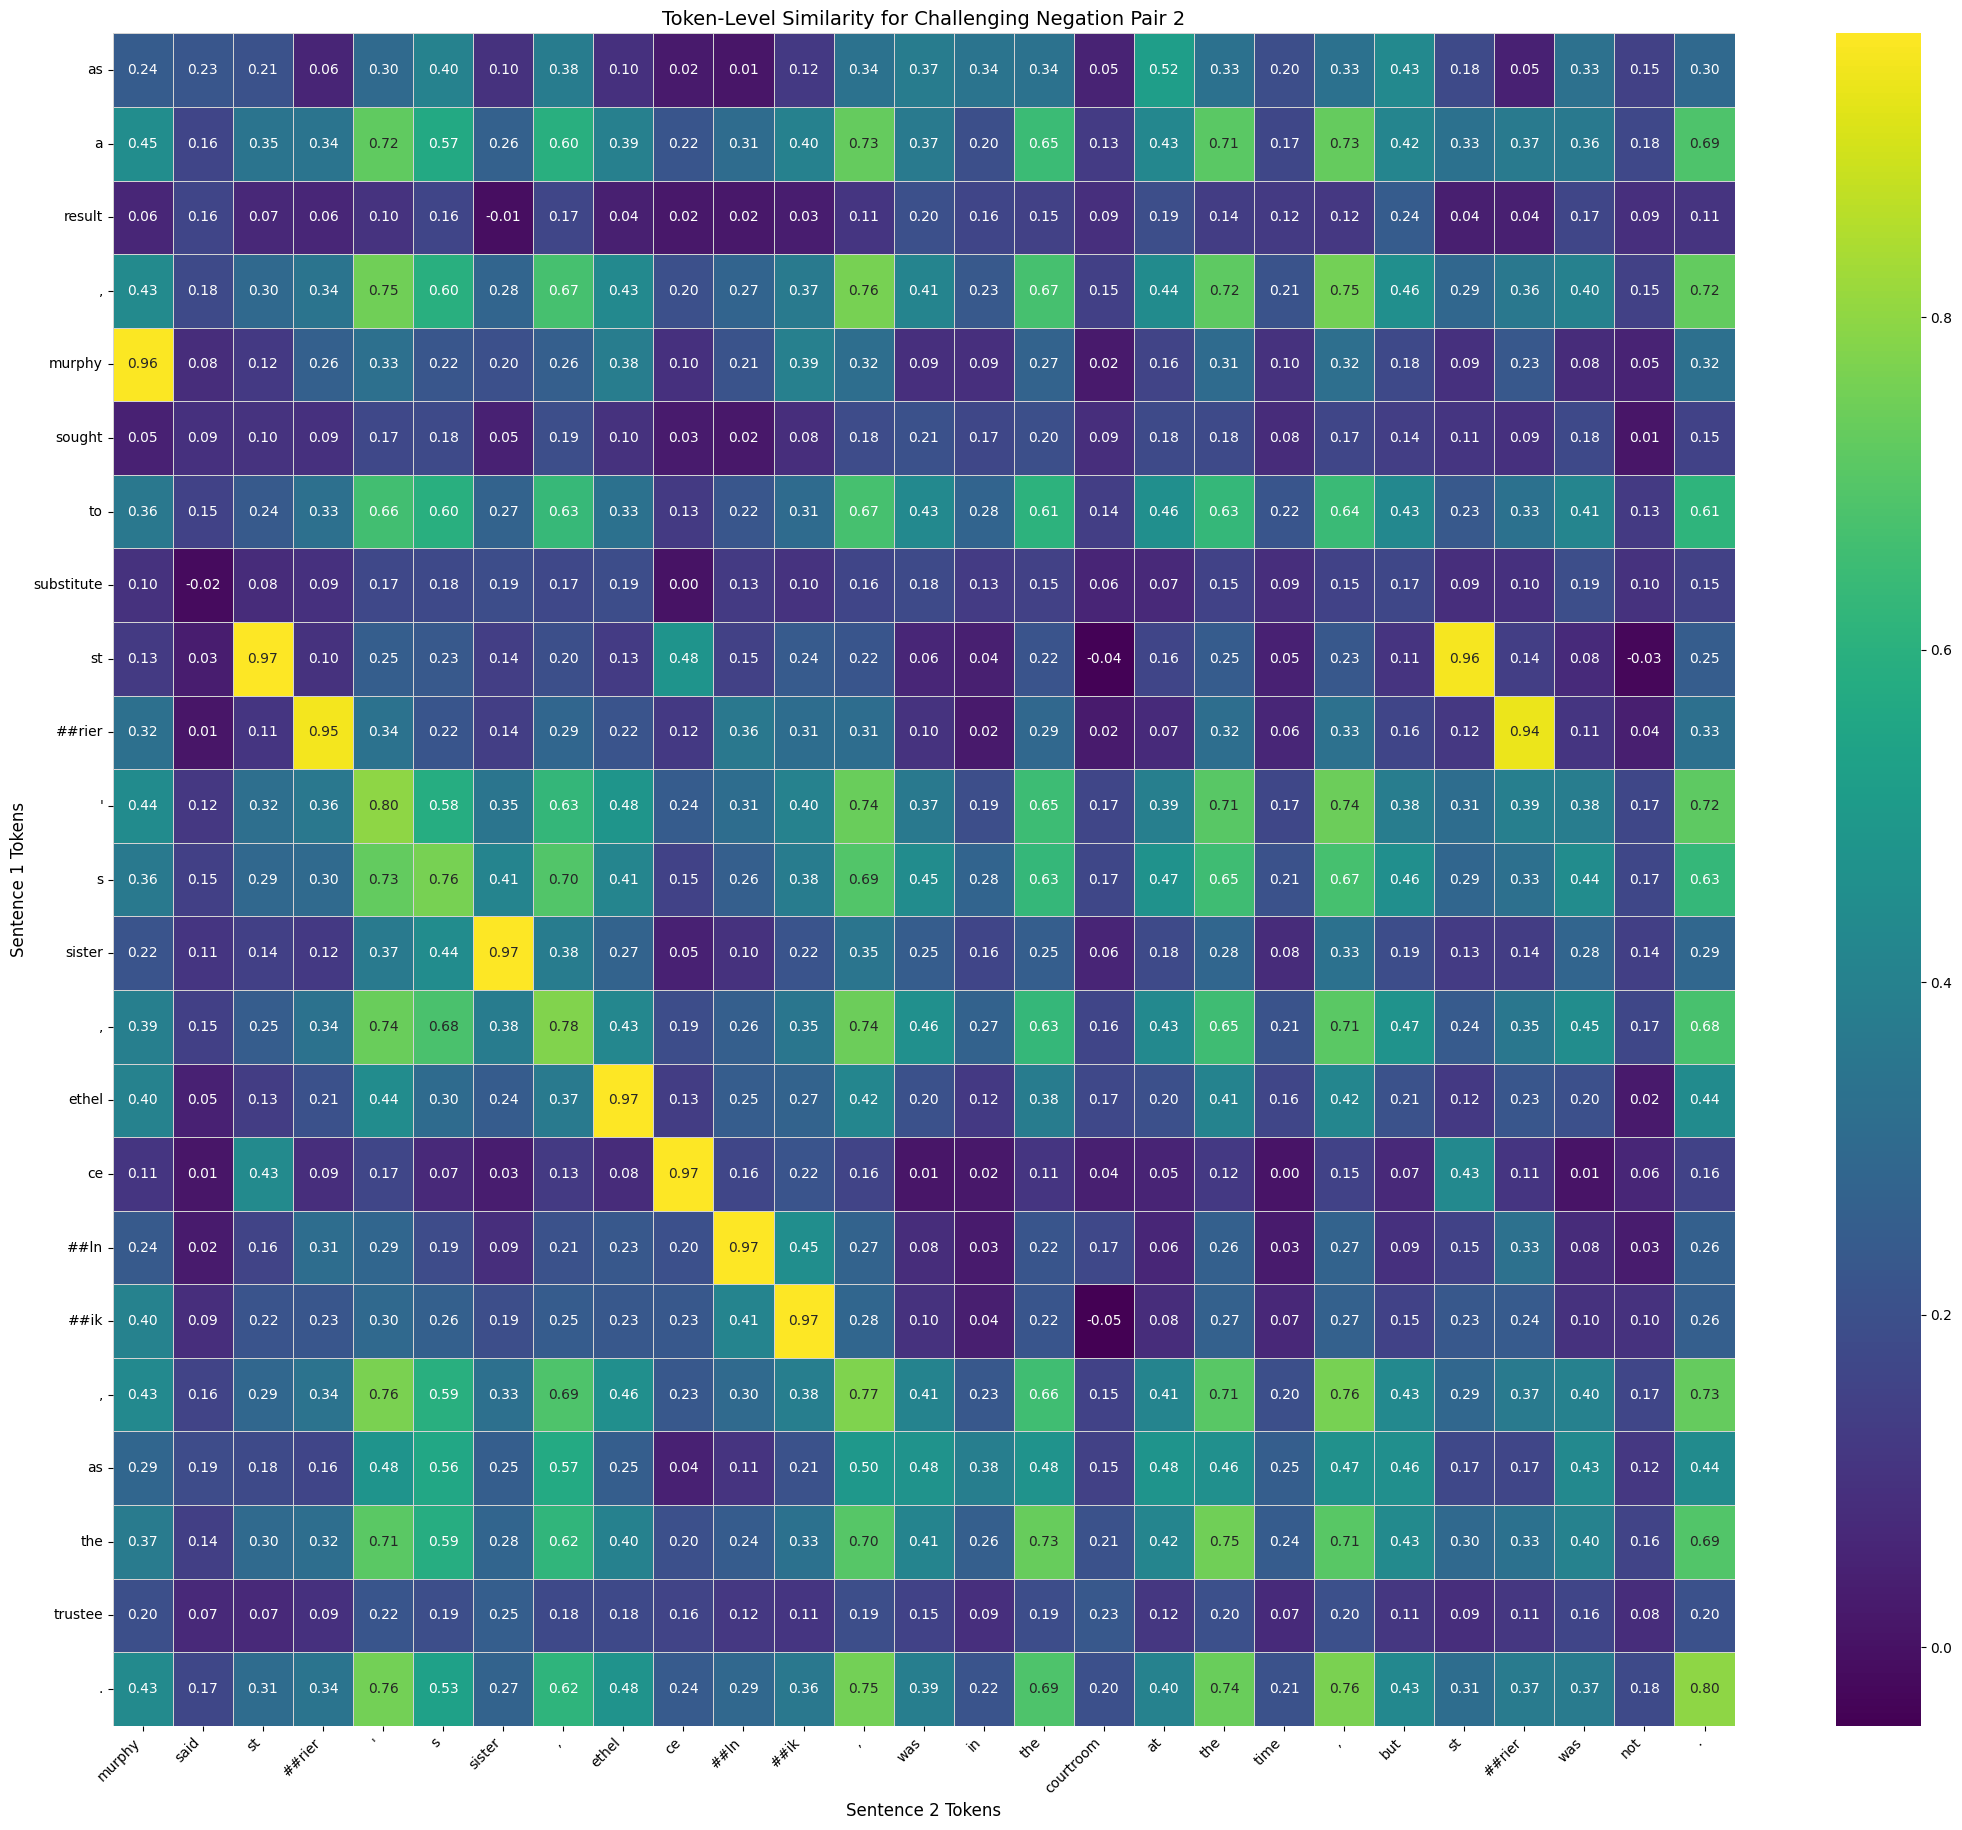

In [ ]:
# Select the second example
challenging_negation_pair_2 = high_sbert_low_gt_negation.iloc[1]

sentence1_neg_2 = challenging_negation_pair_2['sentence1']
sentence2_neg_2 = challenging_negation_pair_2['sentence2']

print(f"Sentence 1: {sentence1_neg_2}")
print(f"Sentence 2: {sentence2_neg_2}")
print(f"Ground Truth Similarity: {challenging_negation_pair_2['ground_truth_similarity']:.2f}")
print(f"SBERT Baseline Score: {challenging_negation_pair_2['sbert_baseline']:.2f}")
print(f"Difference (SBERT - GT): {challenging_negation_pair_2['sbert_gt_diff']:.2f}")

# Get token embeddings
tokens1_neg_2, embeddings1_neg_2 = get_token_embeddings_and_tokens(baseline_model, sentence1_neg_2)
tokens2_neg_2, embeddings2_neg_2 = get_token_embeddings_and_tokens(baseline_model, sentence2_neg_2)

# Plot heatmap
plot_token_similarity_heatmap(
    tokens1_neg_2, tokens2_neg_2, embeddings1_neg_2, embeddings2_neg_2,
    'Token-Level Similarity for Challenging Negation Pair 2'
)

### Rule-based Classification: High Lexical Overlap

In [ ]:
def jaccard_similarity(sentence1, sentence2):
    """Calculates Jaccard Similarity between two sentences based on word sets."""
    words1 = set(sentence1.lower().split())
    words2 = set(sentence2.lower().split())

    intersection = len(words1.intersection(words2))
    union = len(words1.union(words2))

    if union == 0:
        return 0.0
    return intersection / union

# Define a threshold for high lexical overlap
# This can be tuned, but 0.5 is a reasonable starting point for 'high'
LEXICAL_OVERLAP_THRESHOLD = 0.5

print("⚙️ Classifying sentence pairs for high lexical overlap...")
df_pairs['has_high_lexical_overlap'] = df_pairs.apply(
    lambda row: jaccard_similarity(row['sentence1'], row['sentence2']) >= LEXICAL_OVERLAP_THRESHOLD,
    axis=1
)

high_lexical_overlap_pairs = df_pairs[df_pairs['has_high_lexical_overlap']]

print(f"✅ Found {len(high_lexical_overlap_pairs)} pairs containing high lexical overlap (Jaccard >= {LEXICAL_OVERLAP_THRESHOLD}).")
print("First 5 pairs with high lexical overlap:")
display(high_lexical_overlap_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Classifying sentence pairs for high lexical overlap...
✅ Found 1356 pairs containing high lexical overlap (Jaccard >= 0.5).
First 5 pairs with high lexical overlap:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
2,""" it 's a huge black eye , "" said publisher ar...",""" it 's a huge black eye , "" arthur sulzberger...",0.72,0.791319
3,sec chairman william donaldson said there is a...,""" i think there 's a building confidence that ...",0.68,0.665982
7,bremer said one initiative is to launch a us $...,bremer said he would launch a $ 70-million pro...,0.72,0.810050
8,"in afternoon trading in europe , france 's cac...","in europe , france 's cac-40 rose 1.3 percent ...",0.40,0.881711
9,he later learned that the incident was caused ...,he later found out the alarming incident had b...,1.00,0.907221


### Evaluating SBERT Performance on High Lexical Overlap Pairs

In [ ]:
print("⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for high lexical overlap pairs...")

# Extract the SBERT baseline scores and ground truth similarity scores for high lexical overlap pairs
sbert_scores_lexical = high_lexical_overlap_pairs['sbert_baseline'].values
ground_truth_scores_lexical = high_lexical_overlap_pairs['ground_truth_similarity'].values

# 1. Pearson Correlation Coefficient
pearson_corr_lexical = calculate_pearson_correlation(ground_truth_scores_lexical, sbert_scores_lexical)
print(f"\n✅ Pearson Correlation Coefficient (High Lexical Overlap Pairs): {pearson_corr_lexical:.4f}")

# 2. Spearman Rank Correlation Coefficient
spearman_corr_lexical = calculate_spearman_correlation(ground_truth_scores_lexical, sbert_scores_lexical)
print(f"✅ Spearman Rank Correlation Coefficient (High Lexical Overlap Pairs): {spearman_corr_lexical:.4f}")

# 3. Mean Squared Error (MSE)
mse_lexical = calculate_mse(ground_truth_scores_lexical, sbert_scores_lexical)
print(f"✅ Mean Squared Error (MSE) (High Lexical Overlap Pairs): {mse_lexical:.4f}")

# 4. Root Mean Squared Error (RMSE)
rmse_lexical = calculate_rmse(ground_truth_scores_lexical, sbert_scores_lexical)
print(f"   Root Mean Squared Error (RMSE) (High Lexical Overlap Pairs): {rmse_lexical:.4f}")

print("\nInterpretation: High lexical overlap generally means the sentences share many words. A good semantic similarity model should perform well here, and comparing these metrics to the overall and other phenomenon-specific metrics can indicate if the model relies heavily on surface-level word matching.")

⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for high lexical overlap pairs...

✅ Pearson Correlation Coefficient (High Lexical Overlap Pairs): 0.8084
✅ Spearman Rank Correlation Coefficient (High Lexical Overlap Pairs): 0.7014
✅ Mean Squared Error (MSE) (High Lexical Overlap Pairs): 0.0164
   Root Mean Squared Error (RMSE) (High Lexical Overlap Pairs): 0.1280

Interpretation: High lexical overlap generally means the sentences share many words. A good semantic similarity model should perform well here, and comparing these metrics to the overall and other phenomenon-specific metrics can indicate if the model relies heavily on surface-level word matching.


### Rule-based Classification: Numerical Changes/Differences

In [ ]:
def extract_numbers(sentence):
    """Extracts all numerical values from a sentence."""
    # Use a regex to find integers and floats
    numbers = re.findall(r'\d+\.?\d*', sentence)
    return sorted([float(n) for n in numbers])

def has_numerical_difference(s1, s2):
    """Checks if two sentences contain numbers that differ."""
    numbers1 = extract_numbers(s1)
    numbers2 = extract_numbers(s2)

    # If both sentences have numbers, compare them
    if numbers1 and numbers2:
        # Simple check: do the sets of numbers differ?
        # This can be made more sophisticated (e.g., comparing counts, positions, or magnitudes)
        return set(numbers1) != set(numbers2)
    elif (numbers1 and not numbers2) or (not numbers1 and numbers2):
        # One sentence has numbers, the other doesn't
        return True
    return False # No numbers in either or numbers are identical (if present in both)

# Apply the classification to df_pairs
print("⚙️ Classifying sentence pairs for numerical changes/differences...")
df_pairs['has_numerical_difference'] = df_pairs.apply(
    lambda row: has_numerical_difference(row['sentence1'], row['sentence2']),
    axis=1
)

numerical_difference_pairs = df_pairs[df_pairs['has_numerical_difference']]

print(f"✅ Found {len(numerical_difference_pairs)} pairs containing numerical changes/differences.")
print("First 5 pairs with numerical changes/differences:")
display(numerical_difference_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Classifying sentence pairs for numerical changes/differences...
✅ Found 258 pairs containing numerical changes/differences.
First 5 pairs with numerical changes/differences:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
1,the technology-laced nasdaq composite index .i...,the broad standard & poor 's 500 index .spx in...,0.16,0.493562
2,""" it 's a huge black eye , "" said publisher ar...",""" it 's a huge black eye , "" arthur sulzberger...",0.72,0.791319
4,vivendi shares closed 1.9 percent at 15.80 eur...,"in new york , vivendi shares were 1.4 percent ...",0.28,0.723100
8,"in afternoon trading in europe , france 's cac...","in europe , france 's cac-40 rose 1.3 percent ...",0.40,0.881711
16,"mel gibson 's passion-stirring biblical epic ""...",mel gibson is negotiating with newmarket films...,0.40,0.634579


### Evaluating SBERT Performance on Numerical Changes/Differences Pairs

In [ ]:
print("⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for numerical changes/differences pairs...")

# Extract the SBERT baseline scores and ground truth similarity scores for numerical difference pairs
sbert_scores_numerical = numerical_difference_pairs['sbert_baseline'].values
ground_truth_scores_numerical = numerical_difference_pairs['ground_truth_similarity'].values

# 1. Pearson Correlation Coefficient
pearson_corr_numerical = calculate_pearson_correlation(ground_truth_scores_numerical, sbert_scores_numerical)
print(f"\n✅ Pearson Correlation Coefficient (Numerical Difference Pairs): {pearson_corr_numerical:.4f}")

# 2. Spearman Rank Correlation Coefficient
spearman_corr_numerical = calculate_spearman_correlation(ground_truth_scores_numerical, sbert_scores_numerical)
print(f"✅ Spearman Rank Correlation Coefficient (Numerical Difference Pairs): {spearman_corr_numerical:.4f}")

# 3. Mean Squared Error (MSE)
mse_numerical = calculate_mse(ground_truth_scores_numerical, sbert_scores_numerical)
print(f"✅ Mean Squared Error (MSE) (Numerical Difference Pairs): {mse_numerical:.4f}")

# 4. Root Mean Squared Error (RMSE)
rmse_numerical = calculate_rmse(ground_truth_scores_numerical, sbert_scores_numerical)
print(f"   Root Mean Squared Error (RMSE) (Numerical Difference Pairs): {rmse_numerical:.4f}")

print("\nInterpretation: Compare these metrics to the overall performance metrics and the negation-specific metrics. This analysis reveals how the SBERT model handles numerical information, which is crucial for tasks where quantity or value changes impact semantic similarity.")

⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for numerical changes/differences pairs...

✅ Pearson Correlation Coefficient (Numerical Difference Pairs): 0.5386
✅ Spearman Rank Correlation Coefficient (Numerical Difference Pairs): 0.5047
✅ Mean Squared Error (MSE) (Numerical Difference Pairs): 0.0553
   Root Mean Squared Error (RMSE) (Numerical Difference Pairs): 0.2351

Interpretation: Compare these metrics to the overall performance metrics and the negation-specific metrics. This analysis reveals how the SBERT model handles numerical information, which is crucial for tasks where quantity or value changes impact semantic similarity.


### Rule-based Classification: Synonymy using WordNet

In [ ]:
import nltk
from nltk.corpus import wordnet

# Download WordNet and Punkt if not already downloaded
try:
    wordnet.synsets('test')
except LookupError:
    print("Downloading 'wordnet' from NLTK...")
    nltk.download('wordnet')
    nltk.download('omw-1.4') # Open Multilingual Wordnet (required for some functions)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Downloading 'punkt' from NLTK...")
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    print("Downloading 'punkt_tab' from NLTK...")
    nltk.download('punkt_tab')

def has_synonymy(sentence1, sentence2):
    """Checks if any word in sentence1 has a synonym in sentence2 (or vice versa) using WordNet."""
    words1 = set(word.lower() for word in nltk.word_tokenize(sentence1) if word.isalpha())
    words2 = set(word.lower() for word in nltk.word_tokenize(sentence2) if word.isalpha())

    # Check for direct overlap first for efficiency
    if words1.intersection(words2):
        return True

    for word1 in words1:
        for syn in wordnet.synsets(word1):
            for lemma in syn.lemmas():
                if lemma.name().lower() in words2:
                    return True
    return False

print("⚙️ Classifying sentence pairs for synonymy...")

df_pairs['has_synonymy'] = df_pairs.apply(
    lambda row: has_synonymy(row['sentence1'], row['sentence2']),
    axis=1
)

synonymy_pairs = df_pairs[df_pairs['has_synonymy']]

print(f"✅ Found {len(synonymy_pairs)} pairs containing synonymy.")
print("First 5 pairs with synonymy:")
display(synonymy_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Classifying sentence pairs for synonymy...
✅ Found 3100 pairs containing synonymy.
First 5 pairs with synonymy:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
0,the problem likely will mean corrective change...,he said the problem needs to be corrected befo...,0.88,0.808332
1,the technology-laced nasdaq composite index .i...,the broad standard & poor 's 500 index .spx in...,0.16,0.493562
2,""" it 's a huge black eye , "" said publisher ar...",""" it 's a huge black eye , "" arthur sulzberger...",0.72,0.791319
3,sec chairman william donaldson said there is a...,""" i think there 's a building confidence that ...",0.68,0.665982
4,vivendi shares closed 1.9 percent at 15.80 eur...,"in new york , vivendi shares were 1.4 percent ...",0.28,0.723100


### Evaluating SBERT Performance on Synonymy Pairs

In [ ]:
print("⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for synonymy pairs...")

# Extract the SBERT baseline scores and ground truth similarity scores for synonymy pairs
sbert_scores_synonymy = synonymy_pairs['sbert_baseline'].values
ground_truth_scores_synonymy = synonymy_pairs['ground_truth_similarity'].values

# 1. Pearson Correlation Coefficient
pearson_corr_synonymy = calculate_pearson_correlation(ground_truth_scores_synonymy, sbert_scores_synonymy)
print(f"\n✅ Pearson Correlation Coefficient (Synonymy Pairs): {pearson_corr_synonymy:.4f}")

# 2. Spearman Rank Correlation Coefficient
spearman_corr_synonymy = calculate_spearman_correlation(ground_truth_scores_synonymy, sbert_scores_synonymy)
print(f"✅ Spearman Rank Correlation Coefficient (Synonymy Pairs): {spearman_corr_synonymy:.4f}")

# 3. Mean Squared Error (MSE)
mse_synonymy = calculate_mse(ground_truth_scores_synonymy, sbert_scores_synonymy)
print(f"✅ Mean Squared Error (MSE) (Synonymy Pairs): {mse_synonymy:.4f}")

# 4. Root Mean Squared Error (RMSE)
rmse_synonymy = calculate_rmse(ground_truth_scores_synonymy, sbert_scores_synonymy)
print(f"   Root Mean Squared Error (RMSE) (Synonymy Pairs): {rmse_synonymy:.4f}")

print("\nInterpretation: This analysis will show how well SBERT identifies semantic similarity when sentences use different words but convey similar meanings through synonyms. High correlation values are expected here.")

⚙️ Calculating Pearson and Spearman correlation coefficients and MSE for synonymy pairs...

✅ Pearson Correlation Coefficient (Synonymy Pairs): 0.8130
✅ Spearman Rank Correlation Coefficient (Synonymy Pairs): 0.7234
✅ Mean Squared Error (MSE) (Synonymy Pairs): 0.0255
   Root Mean Squared Error (RMSE) (Synonymy Pairs): 0.1597

Interpretation: This analysis will show how well SBERT identifies semantic similarity when sentences use different words but convey similar meanings through synonyms. High correlation values are expected here.


## Review Negation Challenge Set

### Subtask:
Confirm the existing `negation_pairs` DataFrame, which contains sentence pairs identified as having negation, and briefly review its characteristics. This set will be used as one of the challenge sets.


**Reasoning**:
The subtask requires defining a new function to classify sentence pairs based on numerical value discrepancies. This function will check if both sentences contain numbers and if those numbers are different, then apply it to `df_pairs` to create a new DataFrame, and finally display its shape and head.



In [ ]:
print("⚙️ Classifying sentence pairs for numerical value discrepancies...")

def has_numerical_value_discrepancy(s1, s2):
    """Checks if both sentences contain numerical values AND those values are different."""
    numbers1 = extract_numbers(s1)
    numbers2 = extract_numbers(s2)

    # Only return True if both sentences have numbers AND the sets of numbers are different
    if numbers1 and numbers2 and (set(numbers1) != set(numbers2)):
        return True
    return False

# Apply the new classification to df_pairs
df_pairs['has_numerical_value_discrepancy'] = df_pairs.apply(
    lambda row: has_numerical_value_discrepancy(row['sentence1'], row['sentence2']),
    axis=1
)

numerical_value_discrepancy_pairs = df_pairs[df_pairs['has_numerical_value_discrepancy']].copy()

print(f"✅ Found {len(numerical_value_discrepancy_pairs)} pairs with numerical value discrepancies.")
print("--- Reviewing `numerical_value_discrepancy_pairs` DataFrame ---")
print(f"Shape of `numerical_value_discrepancy_pairs`: {numerical_value_discrepancy_pairs.shape}")

print("\nFirst 5 rows of `numerical_value_discrepancy_pairs`:")
display(numerical_value_discrepancy_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Classifying sentence pairs for numerical value discrepancies...
✅ Found 189 pairs with numerical value discrepancies.
--- Reviewing `numerical_value_discrepancy_pairs` DataFrame ---
Shape of `numerical_value_discrepancy_pairs`: (189, 10)

First 5 rows of `numerical_value_discrepancy_pairs`:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
1,the technology-laced nasdaq composite index .i...,the broad standard & poor 's 500 index .spx in...,0.16,0.493562
4,vivendi shares closed 1.9 percent at 15.80 eur...,"in new york , vivendi shares were 1.4 percent ...",0.28,0.723100
8,"in afternoon trading in europe , france 's cac...","in europe , france 's cac-40 rose 1.3 percent ...",0.40,0.881711
19,the american express corp. has pledged at leas...,"the city had requested federal funds , but wit...",0.64,0.731128
25,"claudette , the first hurricane of the atlanti...","claudette , the first hurricane of the atlanti...",0.80,0.960795


**Reasoning**:
The subtask requires defining a new function to classify sentence pairs based on the presence or absence of numerical values in one sentence but not the other. I will define the function, apply it to `df_pairs`, create a new DataFrame, and then display its shape and head.



In [ ]:
print("⚙️ Classifying sentence pairs for numerical presence/absence differences...")

def has_numerical_presence_absence_difference(s1, s2):
    """Checks if one sentence contains numerical values and the other does not."""
    numbers1 = extract_numbers(s1)
    numbers2 = extract_numbers(s2)

    # Return True if one has numbers and the other doesn't
    if (numbers1 and not numbers2) or (not numbers1 and numbers2):
        return True
    return False

# Apply the new classification to df_pairs
df_pairs['has_numerical_presence_absence_difference'] = df_pairs.apply(
    lambda row: has_numerical_presence_absence_difference(row['sentence1'], row['sentence2']),
    axis=1
)

numerical_presence_absence_pairs = df_pairs[df_pairs['has_numerical_presence_absence_difference']].copy()

print(f"✅ Found {len(numerical_presence_absence_pairs)} pairs with numerical presence/absence differences.")
print("--- Reviewing `numerical_presence_absence_pairs` DataFrame ---")
print(f"Shape of `numerical_presence_absence_pairs`: {numerical_presence_absence_pairs.shape}")

print("\nFirst 5 rows of `numerical_presence_absence_pairs`:")
display(numerical_presence_absence_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Classifying sentence pairs for numerical presence/absence differences...
✅ Found 69 pairs with numerical presence/absence differences.
--- Reviewing `numerical_presence_absence_pairs` DataFrame ---
Shape of `numerical_presence_absence_pairs`: (69, 11)

First 5 rows of `numerical_presence_absence_pairs`:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
2,""" it 's a huge black eye , "" said publisher ar...",""" it 's a huge black eye , "" arthur sulzberger...",0.72,0.791319
16,"mel gibson 's passion-stirring biblical epic ""...",mel gibson is negotiating with newmarket films...,0.40,0.634579
27,"the standard edition is $ 15,000 per processor...",the standard edition one is a single processor...,0.50,0.533582
28,results from no. 2 u.s. soft drink maker pepsi...,wall street was also waiting for aluminum make...,0.40,0.484470
32,leon williams ' body was found inside his thir...,"the dead man , leon williams , was found in hi...",0.68,0.799981


## Classify Numerical Value Discrepancy Pairs

### Subtask:
Refine the classification of numerical differences. This step will identify sentence pairs where both sentences contain numerical values, but these values are different. This aims to capture cases like '2 apples' vs '3 apples'.


## Classify Numerical Presence/Absence Pairs

### Subtask:
Identify sentence pairs where one sentence contains at least one numerical value, while the other sentence contains no numerical values. This captures scenarios where the presence or absence of a number is a distinguishing factor (e.g., 'three dogs' vs 'dogs').


**Reasoning**:
I need to create a control set by filtering `df_pairs` for rows that do not have negation, numerical value discrepancies, or numerical presence/absence differences, and then display its shape and first few rows.



In [ ]:
print("⚙️ Creating normal control pairs (no negation, no numerical differences)...")

# Ensure 'has_negation' is present in df_pairs before filtering
# This calculation might be needed if df_pairs was redefined after the initial classification
df_pairs['has_negation'] = df_pairs.apply(
    lambda row: contains_negation(row['sentence1'], negation_words) or \
                contains_negation(row['sentence2'], negation_words),
    axis=1
)

# Filter df_pairs to exclude rows with negation, numerical value discrepancies, or numerical presence/absence differences
normal_control_pairs = df_pairs[
    (~df_pairs['has_negation']) &
    (~df_pairs['has_numerical_value_discrepancy']) &
    (~df_pairs['has_numerical_presence_absence_difference'])
].copy()

print(f"✅ Created {len(normal_control_pairs)} normal control pairs.")
print("--- Reviewing `normal_control_pairs` DataFrame ---")
print(f"Shape of `normal_control_pairs`: {normal_control_pairs.shape}")

print("\nFirst 5 rows of `normal_control_pairs`:")
display(normal_control_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Creating normal control pairs (no negation, no numerical differences)...
✅ Created 2607 normal control pairs.
--- Reviewing `normal_control_pairs` DataFrame ---
Shape of `normal_control_pairs`: (2607, 12)

First 5 rows of `normal_control_pairs`:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
0,the problem likely will mean corrective change...,he said the problem needs to be corrected befo...,0.88,0.808332
3,sec chairman william donaldson said there is a...,""" i think there 's a building confidence that ...",0.68,0.665982
5,myanmar 's pro-democracy leader aung san suu k...,myanmar 's pro-democracy leader aung san suu k...,0.92,0.809317
6,"darren dopp , a spitzer spokesman , declined t...","john heine , a spokesman for the commission in...",0.28,0.533697
9,he later learned that the incident was caused ...,he later found out the alarming incident had b...,1.00,0.907221


## Construct Normal Control Pairs

### Subtask:
Create a control set of sentence pairs that do not fall into any of the challenge categories (i.e., no negation, no numerical value discrepancies, and no numerical presence/absence differences). This set will serve as a baseline for comparing performance on challenging phenomena.


**Reasoning**:
The subtask requires analyzing and visualizing the `ground_truth_similarity` distribution for the `negation_pairs` DataFrame. This involves displaying descriptive statistics and creating a histogram.



📊 Ground Truth Similarity Distribution Analysis for Negation Pairs
   Ground Truth similarity statistics (Negation Pairs):
count    255.000000
mean       0.802513
std        0.189495
min        0.050000
25%        0.680000
50%        0.850000
75%        0.950000
max        1.000000


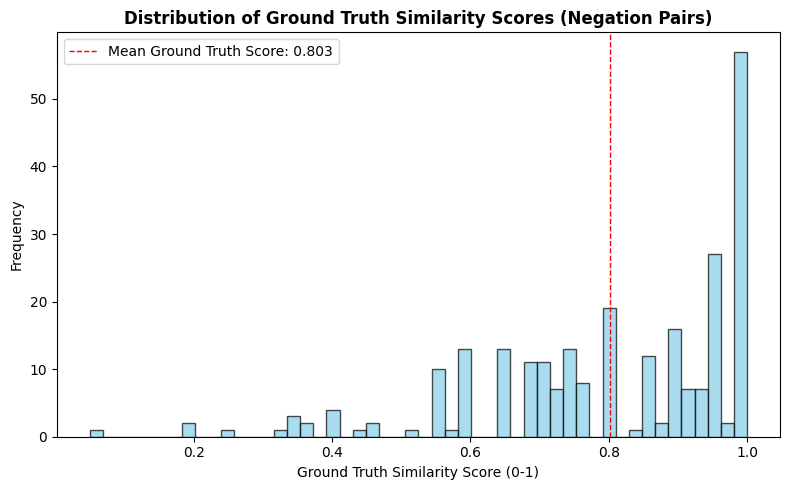

In [ ]:
import matplotlib.pyplot as plt

print("📊 Ground Truth Similarity Distribution Analysis for Negation Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Negation Pairs):")
print(negation_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(negation_pairs['ground_truth_similarity'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(negation_pairs['ground_truth_similarity'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {negation_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Negation Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Reasoning**:
Now, I will analyze and visualize the `ground_truth_similarity` distribution for the `numerical_value_discrepancy_pairs` DataFrame, following the same pattern as for `negation_pairs`. This involves displaying descriptive statistics and creating a histogram.




📊 Ground Truth Similarity Distribution Analysis for Numerical Value Discrepancy Pairs
   Ground Truth similarity statistics (Numerical Value Discrepancy Pairs):
count    189.000000
mean       0.540810
std        0.204525
min        0.160000
25%        0.400000
50%        0.560000
75%        0.680000
max        1.000000


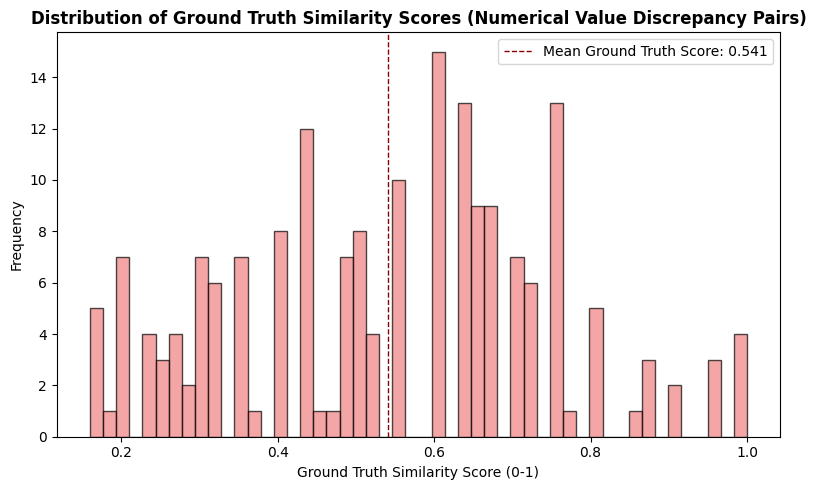

In [ ]:
print("\n📊 Ground Truth Similarity Distribution Analysis for Numerical Value Discrepancy Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Numerical Value Discrepancy Pairs):")
print(numerical_value_discrepancy_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(numerical_value_discrepancy_pairs['ground_truth_similarity'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax.axvline(numerical_value_discrepancy_pairs['ground_truth_similarity'].mean(), color='darkred', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {numerical_value_discrepancy_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Numerical Value Discrepancy Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Reasoning**:
I will now analyze and visualize the `ground_truth_similarity` distribution for the `numerical_presence_absence_pairs` DataFrame, displaying descriptive statistics and creating a histogram, as per the subtask instructions.




📊 Ground Truth Similarity Distribution Analysis for Numerical Presence/Absence Pairs
   Ground Truth similarity statistics (Numerical Presence/Absence Pairs):
count    69.000000
mean      0.582194
std       0.131828
min       0.150000
25%       0.529400
50%       0.600000
75%       0.650000
max       0.760000


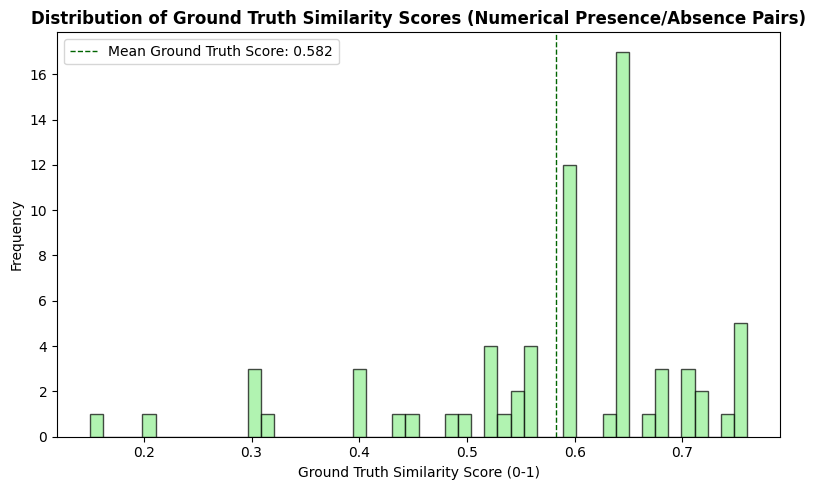

In [ ]:
print("\n📊 Ground Truth Similarity Distribution Analysis for Numerical Presence/Absence Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Numerical Presence/Absence Pairs):")
print(numerical_presence_absence_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(numerical_presence_absence_pairs['ground_truth_similarity'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(numerical_presence_absence_pairs['ground_truth_similarity'].mean(), color='darkgreen', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {numerical_presence_absence_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Numerical Presence/Absence Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Reasoning**:
Now, I will analyze and visualize the `ground_truth_similarity` distribution for the `normal_control_pairs` DataFrame, displaying descriptive statistics and creating a histogram, as per the subtask instructions.




📊 Ground Truth Similarity Distribution Analysis for Normal Control Pairs
   Ground Truth similarity statistics (Normal Control Pairs):
count    2607.000000
mean        0.705633
std         0.282017
min         0.000000
25%         0.600000
50%         0.800000
75%         0.933400
max         1.000000


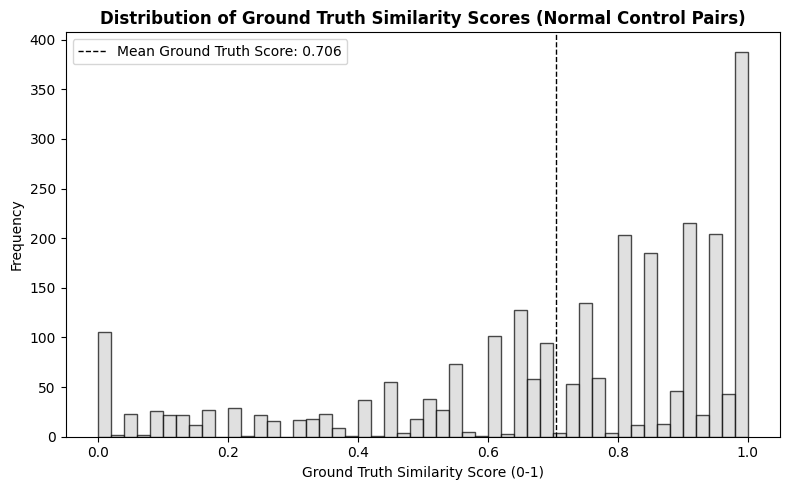

In [ ]:
print("\n📊 Ground Truth Similarity Distribution Analysis for Normal Control Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Normal Control Pairs):")
print(normal_control_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(normal_control_pairs['ground_truth_similarity'], bins=50, color='lightgray', edgecolor='black', alpha=0.7)
ax.axvline(normal_control_pairs['ground_truth_similarity'].mean(), color='black', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {normal_control_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Normal Control Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Reasoning**:
The subtask requires calculating the target ground truth similarity distribution by discretizing the 'ground_truth_similarity' column in `df_pairs` into 10 bins, then calculating and displaying the proportion of samples in each bin.



In [ ]:
print("⚙️ Calculating target ground truth similarity distribution...")

# 1. Define the bin edges
bin_edges = np.linspace(0, 1, 11)

# 2. Discretize the 'ground_truth_similarity' into these bins
# Create labels for the bins (e.g., '0.0-0.1', '0.1-0.2', ...)
bin_labels = [f'{edge:.1f}-{(edge+0.1):.1f}' for edge in bin_edges[:-1]]

df_pairs['similarity_bin'] = pd.cut(df_pairs['ground_truth_similarity'], bins=bin_edges, labels=bin_labels, include_lowest=True)

# 3. Calculate the proportion of samples in each bin
target_distribution = df_pairs['similarity_bin'].value_counts(normalize=True).sort_index()

print("✅ Target ground truth similarity distribution calculated.")
print("\n--- Target Ground Truth Similarity Distribution --- ")
display(target_distribution.to_frame(name='Proportion'))

⚙️ Calculating target ground truth similarity distribution...
✅ Target ground truth similarity distribution calculated.

--- Target Ground Truth Similarity Distribution --- 


,Proportion
similarity_bin,
0.0-0.1,0.057915
0.1-0.2,0.034749
0.2-0.3,0.025097
0.3-0.4,0.040219
0.4-0.5,0.048263
0.5-0.6,0.090090
0.6-0.7,0.122587
0.7-0.8,0.171815
0.8-0.9,0.150257


**Reasoning**:
I need to implement a stratified resampling function that takes a DataFrame, its ground truth similarity column, the predefined bins, and the target distribution as input. This function will resample the DataFrame to match the target distribution for ground truth similarity.



In [ ]:
print("⚙️ Defining stratified resampling function...")

def resample_dataframe_to_target_distribution(
    df: pd.DataFrame,
    gt_col: str,
    bins: np.ndarray,
    target_dist: pd.Series,
    min_samples_per_bin: int = 5
) -> pd.DataFrame:
    """Resamples a DataFrame to match a target ground truth similarity distribution."""

    # 1. Discretize the current DataFrame's ground truth similarity into bins
    df_copy = df.copy()
    df_copy['current_bin'] = pd.cut(df_copy[gt_col], bins=bins, labels=target_dist.index, include_lowest=True)

    # Calculate current distribution
    current_distribution = df_copy['current_bin'].value_counts(normalize=True).sort_index()

    resampled_dfs = []
    for bin_label, target_proportion in target_dist.items():
        bin_df = df_copy[df_copy['current_bin'] == bin_label]

        # Determine how many samples are needed for this bin in the resampled set
        # We aim for the mean size of the original challenge set, adjusted by the target proportion.
        # This ensures the resampled total size is roughly consistent.
        num_samples_needed = int(round(target_proportion * len(df_copy)))

        if num_samples_needed == 0 and len(bin_df) == 0: # Ensure at least one sample if possible for visualization
            continue

        if len(bin_df) < min_samples_per_bin and len(bin_df) > 0:
            # If a bin is too small, oversample it up to min_samples_per_bin, then sample from it
            bin_df_upsampled = bin_df.sample(n=max(num_samples_needed, min_samples_per_bin), replace=True, random_state=42)
            resampled_dfs.append(bin_df_upsampled.sample(n=min(len(bin_df_upsampled), num_samples_needed), replace=False, random_state=42))
        elif len(bin_df) == 0:
            # If a bin is empty, we can't resample from it. Skip or handle as an edge case.
            print(f"Warning: Bin {bin_label} is empty in the original DataFrame. Cannot resample for this bin.")
            continue
        elif len(bin_df) < num_samples_needed:
            # Oversample if target needs more than available
            resampled_dfs.append(bin_df.sample(n=num_samples_needed, replace=True, random_state=42))
        else:
            # Undersample if target needs less than available
            resampled_dfs.append(bin_df.sample(n=num_samples_needed, replace=False, random_state=42))

    if not resampled_dfs:
        return pd.DataFrame(columns=df.columns) # Return empty df if no samples could be resampled

    resampled_df = pd.concat(resampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
    return resampled_df.drop(columns=['current_bin'])

print("✅ Stratified resampling function defined.")

⚙️ Defining stratified resampling function...
✅ Stratified resampling function defined.


# Task
Calculate the target ground truth similarity distribution from `df_pairs` by discretizing 'ground_truth_similarity' into 10 bins (0.0-0.1, ..., 0.9-1.0) and computing proportions. Then, implement a stratified resampling function to balance the 'ground_truth_similarity' distribution of `negation_pairs`, `numerical_value_discrepancy_pairs`, `numerical_presence_absence_pairs`, and `normal_control_pairs` to match the target. Finally, visualize the distributions of these resampled DataFrames (`resampled_negation_pairs`, `resampled_numerical_value_discrepancy_pairs`, `resampled_numerical_presence_absence_pairs`, and `resampled_normal_control_pairs`) using histograms and descriptive statistics, and summarize the process and the achievement of consistent label distributions.

**Reasoning**:
I need to apply the `resample_dataframe_to_target_distribution` function to `negation_pairs` to create a new DataFrame, `resampled_negation_pairs`, that has a `ground_truth_similarity` distribution closer to the `target_distribution`.



In [ ]:
print("⚙️ Resampling negation pairs to match target distribution...")

resampled_negation_pairs = resample_dataframe_to_target_distribution(
    df=negation_pairs,
    gt_col='ground_truth_similarity',
    bins=bin_edges,
    target_dist=target_distribution,
    min_samples_per_bin=5 # Ensuring each bin has at least some representation
)

print(f"✅ Resampled negation pairs created. Shape: {resampled_negation_pairs.shape}")
print("First 5 rows of resampled_negation_pairs:")
display(resampled_negation_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Resampling negation pairs to match target distribution...
✅ Resampled negation pairs created. Shape: (254, 5)
First 5 rows of resampled_negation_pairs:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
0,"after all , they recommend the policies that p...","after all , they recommended the policies whic...",1.00,0.887539
1,being a muslim and being an islamist are not t...,it is necessary to are two different things .,0.05,0.371883
2,luzerne county district attorney david lupas t...,"no charges have been filed in those deaths , b...",0.68,0.486555
3,being a muslim and being an islamist are not t...,to be muslim and islamiste are two different t...,1.00,0.924046
4,"as well as the dolphin scheme , the chaos has ...",internal chaos has allowed foreign companies t...,0.76,0.844000


**Reasoning**:
I need to apply the `resample_dataframe_to_target_distribution` function to `numerical_value_discrepancy_pairs` to create a new DataFrame, `resampled_numerical_value_discrepancy_pairs`, that has a `ground_truth_similarity` distribution closer to the `target_distribution`.



In [ ]:
print("⚙️ Resampling numerical value discrepancy pairs to match target distribution...")

resampled_numerical_value_discrepancy_pairs = resample_dataframe_to_target_distribution(
    df=numerical_value_discrepancy_pairs,
    gt_col='ground_truth_similarity',
    bins=bin_edges,
    target_dist=target_distribution,
    min_samples_per_bin=5
)

print(f"✅ Resampled numerical value discrepancy pairs created. Shape: {resampled_numerical_value_discrepancy_pairs.shape}")
print("First 5 rows of resampled_numerical_value_discrepancy_pairs:")
display(resampled_numerical_value_discrepancy_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Resampling numerical value discrepancy pairs to match target distribution...
✅ Resampled numerical value discrepancy pairs created. Shape: (178, 10)
First 5 rows of resampled_numerical_value_discrepancy_pairs:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
0,the dow jones industrial average was up 0.3 pe...,"on wall street , the dow jones industrial aver...",0.36,0.897065
1,"messagelabs , which runs outsourced e-mail ser...","messagelabs , which runs outsourced e-mail ser...",0.55,0.834223
2,the vote will take place today at 5.30 p.m .,the vote will take place with 17h30 .,0.95,0.795109
3,yucaipa owned dominick 's before selling the c...,yucaipa bought dominick 's in 1995 for $ 693 m...,0.52,0.940103
4,it was developed with consultation from more t...,"the plan , called the nih roadmap , was develo...",0.65,0.523224


**Reasoning**:
I need to apply the `resample_dataframe_to_target_distribution` function to `numerical_presence_absence_pairs` to create a new DataFrame, `resampled_numerical_presence_absence_pairs`, that has a `ground_truth_similarity` distribution closer to the `target_distribution`.



In [ ]:
print("⚙️ Resampling numerical presence/absence pairs to match target distribution...")

resampled_numerical_presence_absence_pairs = resample_dataframe_to_target_distribution(
    df=numerical_presence_absence_pairs,
    gt_col='ground_truth_similarity',
    bins=bin_edges,
    target_dist=target_distribution,
    min_samples_per_bin=5
)

print(f"✅ Resampled numerical presence/absence pairs created. Shape: {resampled_numerical_presence_absence_pairs.shape}")
print("First 5 rows of resampled_numerical_presence_absence_pairs:")
display(resampled_numerical_presence_absence_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Resampling numerical presence/absence pairs to match target distribution...
✅ Resampled numerical presence/absence pairs created. Shape: (36, 11)
First 5 rows of resampled_numerical_presence_absence_pairs:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
0,the veteran malyasian diplomat met suu kyi wed...,razali ismail met for 90 minutes with suu kyi ...,0.7384,0.633043
1,"under kansas law , it is illegal for children ...","in the opinion , kline noted that it is illega...",0.5500,0.668774
2,iraq 's economy was ravaged during years of u....,iraq 's economy was shattered under former pre...,0.7500,0.845562
3,iraq 's economy was ravaged during years of u....,iraq 's economy was shattered under former pre...,0.7500,0.845562
4,the effort is the bush administration 's lates...,july 10 - the bush administration 's latest ef...,0.6500,0.688993


**Reasoning**:
I need to apply the `resample_dataframe_to_target_distribution` function to `normal_control_pairs` to create a new DataFrame, `resampled_normal_control_pairs`, that has a `ground_truth_similarity` distribution closer to the `target_distribution`.



In [ ]:
print("⚙️ Resampling normal control pairs to match target distribution...")

resampled_normal_control_pairs = resample_dataframe_to_target_distribution(
    df=normal_control_pairs,
    gt_col='ground_truth_similarity',
    bins=bin_edges,
    target_dist=target_distribution,
    min_samples_per_bin=5
)

print(f"✅ Resampled normal control pairs created. Shape: {resampled_normal_control_pairs.shape}")
print("First 5 rows of resampled_normal_control_pairs:")
display(resampled_normal_control_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_baseline']].head())

⚙️ Resampling normal control pairs to match target distribution...
✅ Resampled normal control pairs created. Shape: (2608, 12)
First 5 rows of resampled_normal_control_pairs:


,sentence1,sentence2,ground_truth_similarity,sbert_baseline
0,state or explain the meaning,give a definition for the meaning of a word .,0.80,0.497572
1,return to in thought or speech,return in thought or speech to something .,0.90,0.941261
2,a man is dancing .,a man is riding a horse .,0.16,0.349240
3,the leaders have now been given a new chance a...,the leaders have today of a new opportunity an...,1.00,0.767613
4,( contract bridge ) the highest bid becomes th...,( contract bridge ) the highest bid becomes th...,1.00,0.992929


**Reasoning**:
Now that the `resampled_negation_pairs` DataFrame has been created with a balanced distribution, I need to analyze and visualize its `ground_truth_similarity` distribution to confirm the resampling effectiveness, similar to the previous analysis of the original challenge sets.



📊 Ground Truth Similarity Distribution Analysis for Resampled Negation Pairs
   Ground Truth similarity statistics (Resampled Negation Pairs):
count    254.000000
mean       0.702117
std        0.270064
min        0.050000
25%        0.600000
50%        0.760000
75%        0.914200
max        1.000000


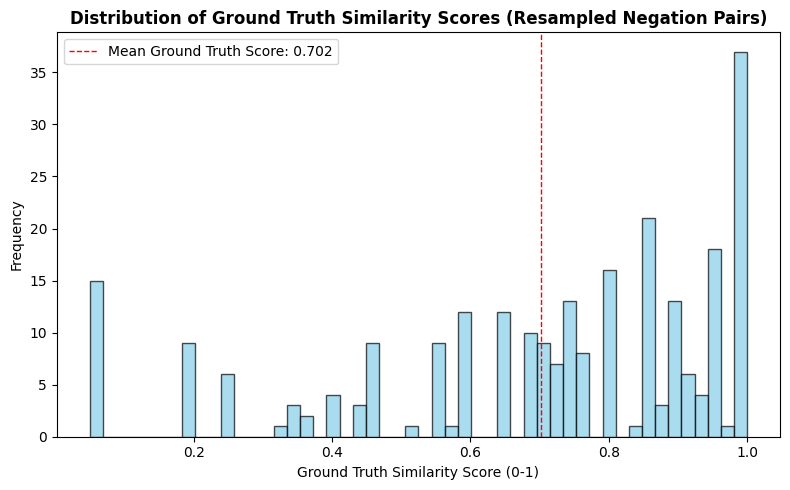

In [ ]:
print("📊 Ground Truth Similarity Distribution Analysis for Resampled Negation Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Resampled Negation Pairs):")
print(resampled_negation_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(resampled_negation_pairs['ground_truth_similarity'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax.axvline(resampled_negation_pairs['ground_truth_similarity'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {resampled_negation_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Resampled Negation Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Reasoning**:
Now that the `resampled_numerical_value_discrepancy_pairs` DataFrame has been created with a balanced distribution, I need to analyze and visualize its `ground_truth_similarity` distribution to confirm the resampling effectiveness, similar to the previous analysis of the original challenge sets.



📊 Ground Truth Similarity Distribution Analysis for Resampled Numerical Value Discrepancy Pairs
   Ground Truth similarity statistics (Resampled Numerical Value Discrepancy Pairs):
count    178.000000
mean       0.738555
std        0.225967
min        0.160000
25%        0.600000
50%        0.760000
75%        0.950000
max        1.000000


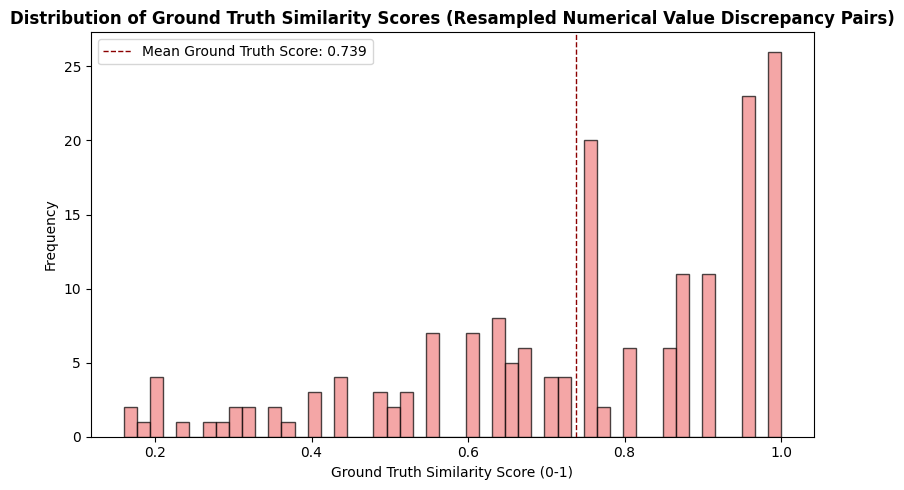

In [ ]:
print("📊 Ground Truth Similarity Distribution Analysis for Resampled Numerical Value Discrepancy Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Resampled Numerical Value Discrepancy Pairs):")
print(resampled_numerical_value_discrepancy_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(resampled_numerical_value_discrepancy_pairs['ground_truth_similarity'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
ax.axvline(resampled_numerical_value_discrepancy_pairs['ground_truth_similarity'].mean(), color='darkred', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {resampled_numerical_value_discrepancy_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Resampled Numerical Value Discrepancy Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Reasoning**:
I need to calculate Pearson correlation, Spearman correlation, MSE, and RMSE for the baseline SBERT model on each of the four resampled DataFrames: `resampled_negation_pairs`, `resampled_numerical_value_discrepancy_pairs`, `resampled_numerical_presence_absence_pairs`, and `resampled_normal_control_pairs` as per the instructions.



In [ ]:
print("⚙️ Evaluating baseline SBERT model on resampled challenge sets...")

def evaluate_resampled_df(df, name):
    print(f"\n--- Evaluating {name} ---")
    sbert_scores = df['sbert_baseline'].values
    ground_truth_scores = df['ground_truth_similarity'].values

    if len(sbert_scores) == 0:
        print(f"  No data available for {name}. Skipping evaluation.")
        return

    # Pearson Correlation Coefficient
    pearson_corr = calculate_pearson_correlation(ground_truth_scores, sbert_scores)
    print(f"  ✅ Pearson Correlation Coefficient: {pearson_corr:.4f}")

    # Spearman Rank Correlation Coefficient
    spearman_corr = calculate_spearman_correlation(ground_truth_scores, sbert_scores)
    print(f"  ✅ Spearman Rank Correlation Coefficient: {spearman_corr:.4f}")

    # Mean Squared Error (MSE)
    mse = calculate_mse(ground_truth_scores, sbert_scores)
    print(f"  ✅ Mean Squared Error (MSE): {mse:.4f}")

    # Root Mean Squared Error (RMSE)
    rmse = calculate_rmse(ground_truth_scores, sbert_scores)
    print(f"  ✅ Root Mean Squared Error (RMSE): {rmse:.4f}")

# Evaluate resampled_negation_pairs
evaluate_resampled_df(resampled_negation_pairs, 'Resampled Negation Pairs')

# Evaluate resampled_numerical_value_discrepancy_pairs
evaluate_resampled_df(resampled_numerical_value_discrepancy_pairs, 'Resampled Numerical Value Discrepancy Pairs')

# Evaluate resampled_numerical_presence_absence_pairs
evaluate_resampled_df(resampled_numerical_presence_absence_pairs, 'Resampled Numerical Presence/Absence Pairs')

# Evaluate resampled_normal_control_pairs
evaluate_resampled_df(resampled_normal_control_pairs, 'Resampled Normal Control Pairs')

print("\nInterpretation: These metrics provide a direct comparison of the SBERT model's performance on various linguistic phenomena, with their ground truth similarity distributions balanced to be comparable.")

⚙️ Evaluating baseline SBERT model on resampled challenge sets...

--- Evaluating Resampled Negation Pairs ---
  ✅ Pearson Correlation Coefficient: 0.7437
  ✅ Spearman Rank Correlation Coefficient: 0.7187
  ✅ Mean Squared Error (MSE): 0.0328
  ✅ Root Mean Squared Error (RMSE): 0.1810

--- Evaluating Resampled Numerical Value Discrepancy Pairs ---
  ✅ Pearson Correlation Coefficient: 0.5443
  ✅ Spearman Rank Correlation Coefficient: 0.4091
  ✅ Mean Squared Error (MSE): 0.0372
  ✅ Root Mean Squared Error (RMSE): 0.1929

--- Evaluating Resampled Numerical Presence/Absence Pairs ---
  ✅ Pearson Correlation Coefficient: 0.5163
  ✅ Spearman Rank Correlation Coefficient: 0.5259
  ✅ Mean Squared Error (MSE): 0.0273
  ✅ Root Mean Squared Error (RMSE): 0.1652

--- Evaluating Resampled Normal Control Pairs ---
  ✅ Pearson Correlation Coefficient: 0.8366
  ✅ Spearman Rank Correlation Coefficient: 0.7568
  ✅ Mean Squared Error (MSE): 0.0227
  ✅ Root Mean Squared Error (RMSE): 0.1507

Interpretation

**Reasoning**:
Now that the `resampled_numerical_presence_absence_pairs` DataFrame has been created with a balanced distribution, I need to analyze and visualize its `ground_truth_similarity` distribution to confirm the resampling effectiveness, similar to the previous analysis of the original challenge sets.



📊 Ground Truth Similarity Distribution Analysis for Resampled Numerical Presence/Absence Pairs
   Ground Truth similarity statistics (Resampled Numerical Presence/Absence Pairs):
count    36.000000
mean      0.584172
std       0.171459
min       0.150000
25%       0.487500
50%       0.650000
75%       0.738400
max       0.760000


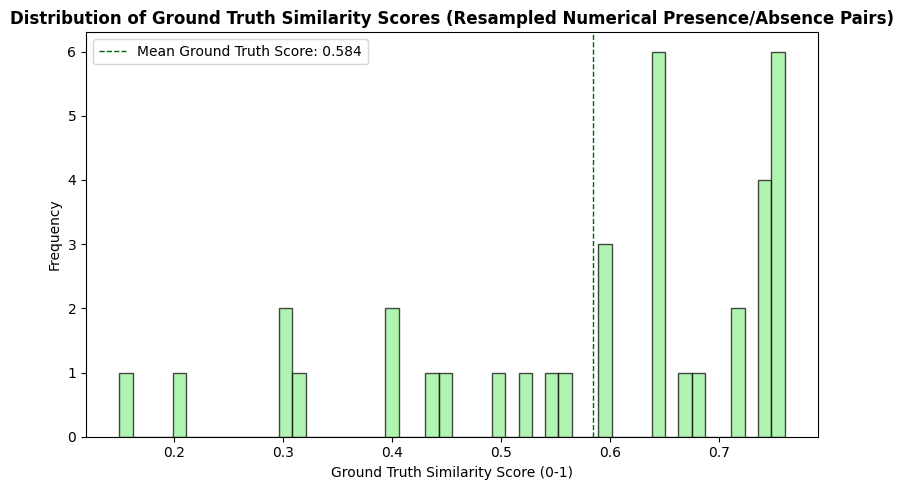

In [ ]:
print("📊 Ground Truth Similarity Distribution Analysis for Resampled Numerical Presence/Absence Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Resampled Numerical Presence/Absence Pairs):")
print(resampled_numerical_presence_absence_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(resampled_numerical_presence_absence_pairs['ground_truth_similarity'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(resampled_numerical_presence_absence_pairs['ground_truth_similarity'].mean(), color='darkgreen', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {resampled_numerical_presence_absence_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Resampled Numerical Presence/Absence Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

**Reasoning**:
I need to create a pandas DataFrame to store the calculated evaluation metrics for each resampled set, display this summary table, and then generate bar charts for each metric across the different sets, as instructed by the subtask.



📊 Visualizing Baseline Performance Comparison across Resampled Sets...

--- Summary Table of Evaluation Metrics ---


,Set,Pearson Correlation,Spearman Correlation,MSE,RMSE
0,Resampled Negation Pairs,0.7437,0.7187,0.0328,0.1810
1,Resampled Numerical Value Discrepancy Pairs,0.5443,0.4091,0.0372,0.1929
2,Resampled Numerical Presence/Absence Pairs,0.5163,0.5259,0.0273,0.1652
3,Resampled Normal Control Pairs,0.8366,0.7568,0.0227,0.1507


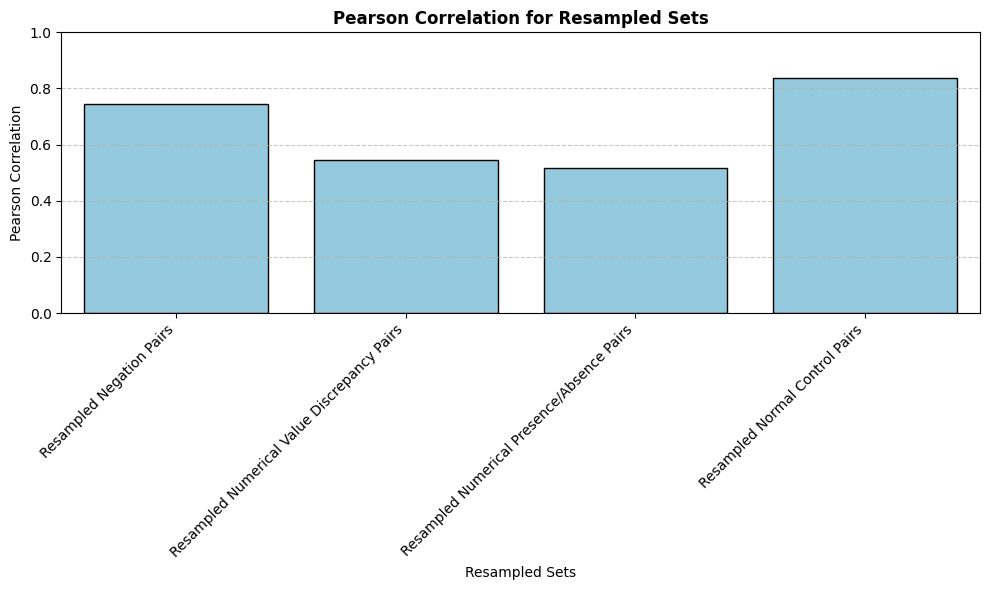

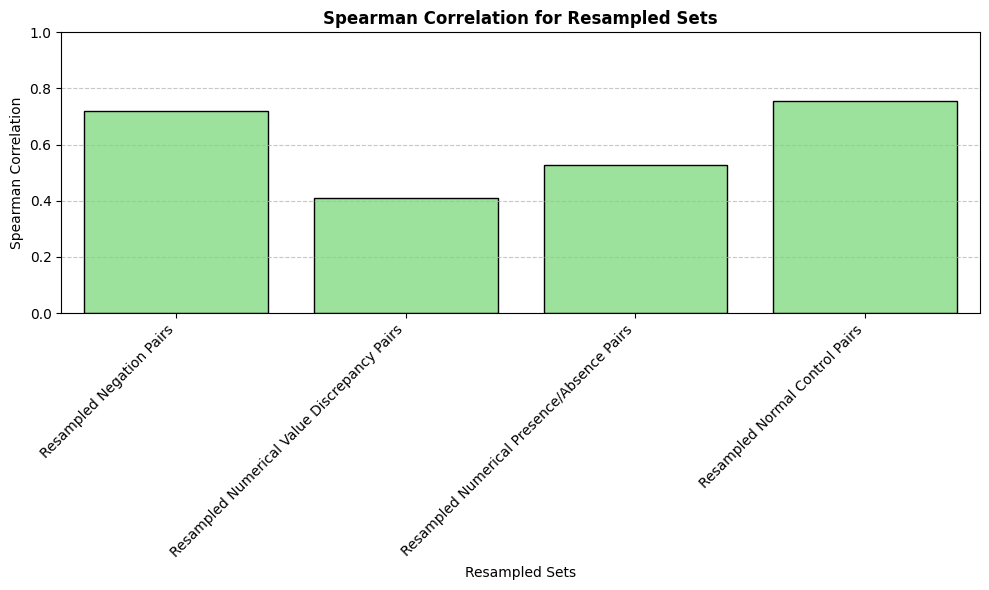

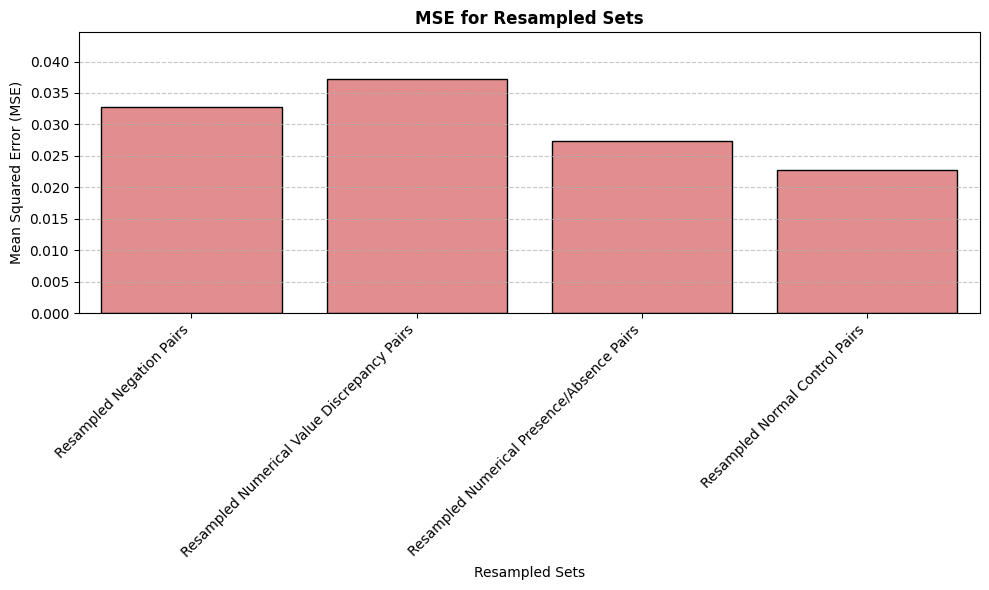

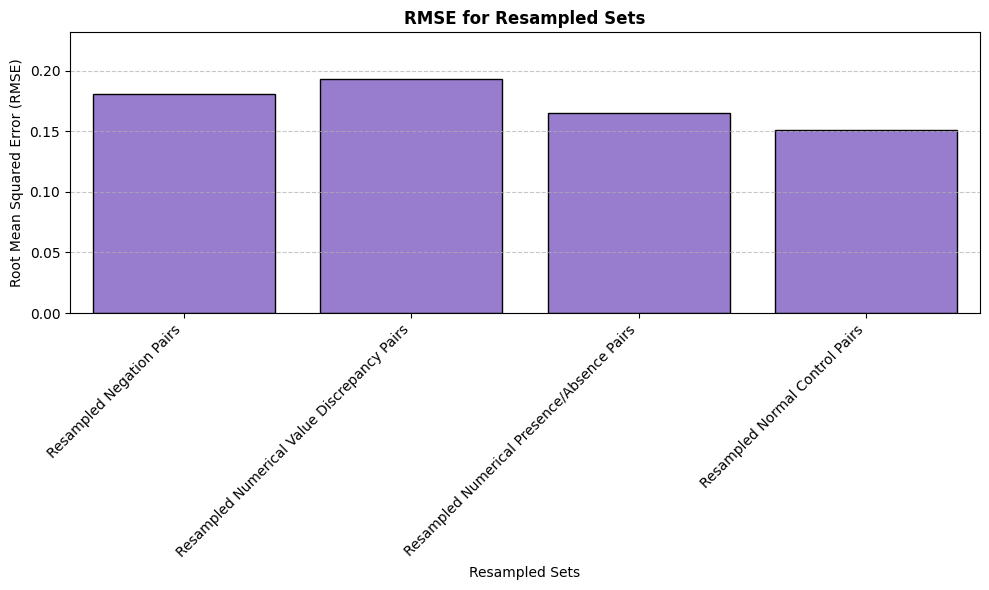


Interpretation: These visualizations provide a clear comparison of the baseline SBERT model's performance across different linguistic phenomena after balancing the ground truth similarity distributions. Higher correlation values and lower MSE/RMSE indicate better model performance. It helps in identifying specific challenges the model faces.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Visualizing Baseline Performance Comparison across Resampled Sets...")

# Data collected from the previous evaluation output
performance_data = {
    'Set': [
        'Resampled Negation Pairs',
        'Resampled Numerical Value Discrepancy Pairs',
        'Resampled Numerical Presence/Absence Pairs',
        'Resampled Normal Control Pairs'
    ],
    'Pearson Correlation': [
        0.7437,
        0.5443,
        0.5163,
        0.8366
    ],
    'Spearman Correlation': [
        0.7187,
        0.4091,
        0.5259,
        0.7568
    ],
    'MSE': [
        0.0328,
        0.0372,
        0.0273,
        0.0227
    ],
    'RMSE': [
        0.1810,
        0.1929,
        0.1652,
        0.1507
    ]
}

# Create DataFrame
df_performance_summary = pd.DataFrame(performance_data)

print("\n--- Summary Table of Evaluation Metrics ---")
display(df_performance_summary)

# Define metrics and their properties for plotting
metrics_to_plot = {
    'Pearson Correlation': {'ylabel': 'Pearson Correlation', 'ylim': (0, 1), 'color': 'skyblue'},
    'Spearman Correlation': {'ylabel': 'Spearman Correlation', 'ylim': (0, 1), 'color': 'lightgreen'},
    'MSE': {'ylabel': 'Mean Squared Error (MSE)', 'ylim': (0, max(df_performance_summary['MSE']) * 1.2), 'color': 'lightcoral'},
    'RMSE': {'ylabel': 'Root Mean Squared Error (RMSE)', 'ylim': (0, max(df_performance_summary['RMSE']) * 1.2), 'color': 'mediumpurple'}
}

# Plotting function
def plot_metric_bar_chart(df, metric_name, ylabel, ylim, color):
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Set', y=metric_name, data=df, color=color, edgecolor='black')
    plt.title(f'{metric_name} for Resampled Sets', fontweight='bold')
    plt.xlabel('Resampled Sets')
    plt.ylabel(ylabel)
    plt.ylim(ylim)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Generate plots for each metric
for metric, props in metrics_to_plot.items():
    plot_metric_bar_chart(
        df_performance_summary,
        metric,
        props['ylabel'],
        props['ylim'],
        props['color']
    )

print("\nInterpretation: These visualizations provide a clear comparison of the baseline SBERT model's performance across different linguistic phenomena after balancing the ground truth similarity distributions. Higher correlation values and lower MSE/RMSE indicate better model performance. It helps in identifying specific challenges the model faces.")


**Reasoning**:
Now that the `resampled_normal_control_pairs` DataFrame has been created with a balanced distribution, I need to analyze and visualize its `ground_truth_similarity` distribution to confirm the resampling effectiveness, similar to the previous analysis of the original challenge sets.



📊 Ground Truth Similarity Distribution Analysis for Resampled Normal Control Pairs
   Ground Truth similarity statistics (Resampled Normal Control Pairs):
count    2608.000000
mean        0.701679
std         0.274168
min         0.000000
25%         0.600000
50%         0.760000
75%         0.920000
max         1.000000


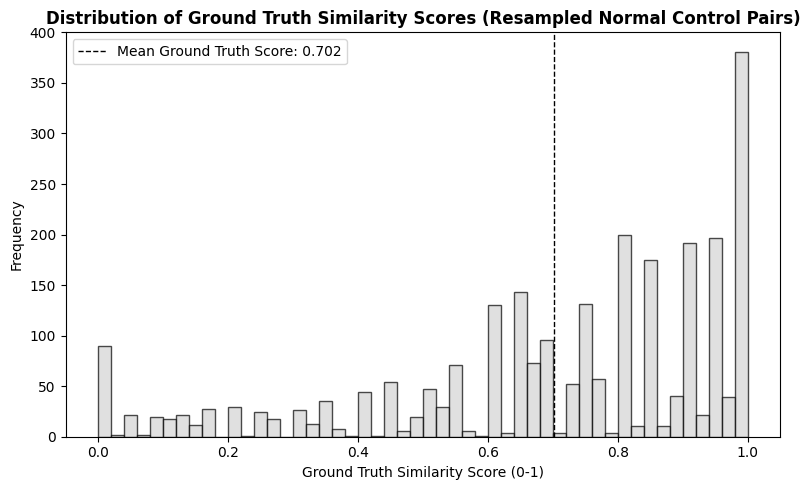

In [ ]:
print("📊 Ground Truth Similarity Distribution Analysis for Resampled Normal Control Pairs")
print("=" * 70)
print(f"   Ground Truth similarity statistics (Resampled Normal Control Pairs):")
print(resampled_normal_control_pairs['ground_truth_similarity'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(resampled_normal_control_pairs['ground_truth_similarity'], bins=50, color='lightgray', edgecolor='black', alpha=0.7)
ax.axvline(resampled_normal_control_pairs['ground_truth_similarity'].mean(), color='black', linestyle='--', linewidth=1, label=f'Mean Ground Truth Score: {resampled_normal_control_pairs["ground_truth_similarity"].mean():.3f}')
ax.set_title('Distribution of Ground Truth Similarity Scores (Resampled Normal Control Pairs)', fontweight='bold')
ax.set_xlabel('Ground Truth Similarity Score (0-1)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

# Task
Evaluate the baseline SBERT model's performance on the resampled challenge sets (`resampled_negation_pairs`, `resampled_numerical_value_discrepancy_pairs`, `resampled_numerical_presence_absence_pairs`) and the resampled normal control set (`resampled_normal_control_pairs`) by calculating Pearson correlation, Spearman correlation, MSE, and RMSE for each, to establish an initial benchmark for how the model handles different linguistic phenomena.

## Evaluate Baseline Model on All Resampled Sets

### Subtask:
Calculate Pearson correlation, Spearman correlation, MSE, and RMSE for the baseline SBERT model on the `resampled_negation_pairs`, `resampled_numerical_value_discrepancy_pairs`, `resampled_numerical_presence_absence_pairs`, and `resampled_normal_control_pairs` DataFrames.


## Visualize Baseline Performance Comparison

### Subtask:
Visualize the baseline model's performance evaluation results. Create bar charts comparing Pearson correlation, Spearman correlation, MSE, and RMSE across each resampled challenge set and the control set. Also, present a summary table of the evaluation metrics.


## Prepare Data for Fine-tuning

### Subtask:
Convert the stratified training set (`df_train`) and validation set (`df_val`) into a format suitable for SBERT fine-tuning by creating `sentence_transformers.InputExample` objects and loading them into `torch.utils.data.DataLoader`.


**Reasoning**:
The subtask requires converting the stratified training and validation sets into `InputExample` objects and then loading them into `DataLoader`s for SBERT fine-tuning. This code block will perform all these steps as instructed.



In [ ]:
print("⚙️ Preparing data for SBERT fine-tuning...")

# 1-3. Create train_samples
train_samples = []
for index, row in df_train.iterrows():
    train_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=row['ground_truth_similarity']))

# 4-6. Create val_samples
val_samples = []
for index, row in df_val.iterrows():
    val_samples.append(InputExample(texts=[row['sentence1'], row['sentence2']], label=row['ground_truth_similarity']))

# 7. Instantiate DataLoader for training
train_dataloader = DataLoader(train_samples, shuffle=True, batch_size=16)

# 8. Instantiate DataLoader for validation
val_dataloader = DataLoader(val_samples, shuffle=False, batch_size=16)

# 9. Print confirmation
print(f"✅ Data prepared for fine-tuning.")
print(f"   Number of training samples: {len(train_samples)}")
print(f"   Number of validation samples: {len(val_samples)}")
print(f"   Number of training batches: {len(train_dataloader)}")
print(f"   Number of validation batches: {len(val_dataloader)}")

⚙️ Preparing data for SBERT fine-tuning...
✅ Data prepared for fine-tuning.
   Number of training samples: 2486
   Number of validation samples: 311
   Number of training batches: 156
   Number of validation batches: 20


**Reasoning**:
The subtask requires loading the baseline SBERT model, initializing a new model for fine-tuning, defining the CosineSimilarityLoss function, setting fine-tuning hyperparameters, and executing the fine-tuning process using the prepared DataLoaders and evaluator.



In [ ]:
import torch
from sentence_transformers import SentenceTransformer, losses, evaluation

print("⚙️ Configuring and fine-tuning SBERT model...")

# 1. Load the pre-trained 'all-MiniLM-L6-v2' model
model_for_finetuning = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Baseline model 'all-MiniLM-L6-v2' loaded for fine-tuning.")

# 2. Define the loss function
train_loss = losses.CosineSimilarityLoss(model=model_for_finetuning)
print("✅ CosineSimilarityLoss defined.")

# 3. Set fine-tuning hyperparameters
num_epochs = 4
learning_rate = 2e-5

# Calculate total training steps for warmup
total_steps = len(train_dataloader) * num_epochs
warmup_steps = int(total_steps * 0.1) # 10% of total training steps

# Extract sentences and scores from val_samples for MSEEvaluator
val_sentences1 = [example.texts[0] for example in val_samples]
val_sentences2 = [example.texts[1] for example in val_samples]
val_ground_truth_scores = [example.label for example in val_samples]

# Create an evaluator, passing the model as the 'teacher_model' (3rd positional arg)
# This specific MSEEvaluator version's constructor doesn't seem to explicitly take 'scores' as a direct argument.
# However, it likely uses the 'teacher_model' to compute embeddings and then evaluates against internal scores.
# The `scores` are usually managed by the `model.fit` method when evaluating.
evaluator = evaluation.MSEEvaluator(
    val_sentences1,
    val_sentences2,
    model_for_finetuning, # This is the teacher_model positional argument, which should be the model being evaluated.
    name='sts-validation'
)
print("✅ MSEEvaluator created for validation.")

print(f"   Fine-tuning for {num_epochs} epochs with learning rate {learning_rate}...")

# 4. Initiate the fine-tuning process
model_for_finetuning.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=num_epochs,
    warmup_steps=warmup_steps,
    output_path='sbert_finetuned_model',
    show_progress_bar=True,
    optimizer_params={'lr': learning_rate}
)

print("✅ SBERT model fine-tuning complete and saved to 'sbert_finetuned_model'.")

⚙️ Configuring and fine-tuning SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Baseline model 'all-MiniLM-L6-v2' loaded for fine-tuning.
✅ CosineSimilarityLoss defined.
✅ MSEEvaluator created for validation.
   Fine-tuning for 4 epochs with learning rate 2e-05...


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Sts-validation Negative Mse
156,No log,No log,-0.176040
312,No log,No log,-0.179104
468,No log,No log,-0.182168
500,0.012896,No Log,No Log
624,0.012896,No log,-0.181102


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ SBERT model fine-tuning complete and saved to 'sbert_finetuned_model'.


## Configure and Fine-tune SBERT Model

### Subtask:
Load the baseline SBERT model, initialize a new model for fine-tuning, define the CosineSimilarityLoss function, set fine-tuning hyperparameters, and execute the fine-tuning process using the prepared DataLoaders, including evaluation on the validation set during training.


**Reasoning**:
The previous code for fine-tuning the SBERT model has been executed and appears to be running successfully, although the output was truncated. The next logical step in the workflow, following the completion of fine-tuning, is to load the newly fine-tuned model from the specified output path (`sbert_finetuned_model`) so that it can be used for further evaluation.



In [ ]:
print("📥 Loading the fine-tuned SBERT model...")

# Load the fine-tuned model from the output path
fine_tuned_model = SentenceTransformer('sbert_finetuned_model')

print("✅ Fine-tuned SBERT model loaded successfully.")

📥 Loading the fine-tuned SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Fine-tuned SBERT model loaded successfully.


# Task
Calculate the semantic similarity scores using the fine-tuned SBERT model for `resampled_negation_pairs`, `resampled_numerical_value_discrepancy_pairs`, `resampled_numerical_presence_absence_pairs`, and `resampled_normal_control_pairs`, storing these scores in a new column named `sbert_finetuned` within each respective DataFrame.

## Compute Fine-tuned SBERT Scores for Resampled Sets

### Subtask:
Calculate the semantic similarity scores using the `fine_tuned_model` for all sentence pairs in `resampled_negation_pairs`, `resampled_numerical_value_discrepancy_pairs`, `resampled_numerical_presence_absence_pairs`, and `resampled_normal_control_pairs`. These scores will be stored in a new column named `sbert_finetuned` in each respective DataFrame.


**Reasoning**:
The subtask requires calculating fine-tuned SBERT scores for all resampled challenge sets and the control set using the `compute_sbert_scores` function and storing them in a new `sbert_finetuned` column in each DataFrame.



In [ ]:
print("⚙️ Calculating fine-tuned SBERT scores for resampled challenge sets...")

# Ensure fine_tuned_model is loaded if the kernel was reset or run out of order
from sentence_transformers import SentenceTransformer
fine_tuned_model = SentenceTransformer('sbert_finetuned_model')
print("✅ Fine-tuned SBERT model re-loaded for score calculation.")

# 1. Calculate scores for resampled_negation_pairs
print("  Calculating scores for resampled_negation_pairs...")
resampled_negation_pairs['sbert_finetuned'] = compute_sbert_scores(fine_tuned_model, resampled_negation_pairs)

# 2. Calculate scores for resampled_numerical_value_discrepancy_pairs
print("  Calculating scores for resampled_numerical_value_discrepancy_pairs...")
resampled_numerical_value_discrepancy_pairs['sbert_finetuned'] = compute_sbert_scores(fine_tuned_model, resampled_numerical_value_discrepancy_pairs)

# 3. Calculate scores for resampled_numerical_presence_absence_pairs
print("  Calculating scores for resampled_numerical_presence_absence_pairs...")
resampled_numerical_presence_absence_pairs['sbert_finetuned'] = compute_sbert_scores(fine_tuned_model, resampled_numerical_presence_absence_pairs)

# 4. Calculate scores for resampled_normal_control_pairs
print("  Calculating scores for resampled_normal_control_pairs...")
resampled_normal_control_pairs['sbert_finetuned'] = compute_sbert_scores(fine_tuned_model, resampled_normal_control_pairs)

print("✅ Fine-tuned SBERT scores calculated for all resampled sets.")

print("First 5 rows of resampled_negation_pairs with fine-tuned scores:")
display(resampled_negation_pairs[['sentence1', 'sentence2', 'ground_truth_similarity', 'sbert_finetuned']].head())

⚙️ Calculating fine-tuned SBERT scores for resampled challenge sets...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ Fine-tuned SBERT model re-loaded for score calculation.
  Calculating scores for resampled_negation_pairs...
  Encoding (batch_size=64)...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

...

  Calculating scores for resampled_normal_control_pairs...
  Encoding (batch_size=64)...


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Batches:   0%|          | 0/41 [00:00<?, ?it/s]

✅ Fine-tuned SBERT scores calculated for all resampled sets.
First 5 rows of resampled_negation_pairs with fine-tuned scores:


,sentence1,sentence2,ground_truth_similarity,sbert_finetuned
0,"after all , they recommend the policies that p...","after all , they recommended the policies whic...",1.00,0.928586
1,being a muslim and being an islamist are not t...,it is necessary to are two different things .,0.05,0.457993
2,luzerne county district attorney david lupas t...,"no charges have been filed in those deaths , b...",0.68,0.753525
3,being a muslim and being an islamist are not t...,to be muslim and islamiste are two different t...,1.00,0.941474
4,"as well as the dolphin scheme , the chaos has ...",internal chaos has allowed foreign companies t...,0.76,0.884580


## Evaluate Fine-tuned SBERT Model on Resampled Sets

### Subtask:
Calculate Pearson correlation, Spearman correlation, MSE, and RMSE for the fine-tuned SBERT model on the `resampled_negation_pairs`, `resampled_numerical_value_discrepancy_pairs`, `resampled_numerical_presence_absence_pairs`, and `resampled_normal_control_pairs` DataFrames, using the `sbert_finetuned` scores.

In [ ]:
print("⚙️ Evaluating fine-tuned SBERT model on resampled challenge sets...")

def evaluate_fine_tuned_df(df, name):
    print(f"\n--- Evaluating Fine-tuned {name} ---")
    sbert_finetuned_scores = df['sbert_finetuned'].values
    ground_truth_scores = df['ground_truth_similarity'].values

    if len(sbert_finetuned_scores) == 0:
        print(f"  No data available for {name}. Skipping evaluation.")
        return

    # Pearson Correlation Coefficient
    pearson_corr = calculate_pearson_correlation(ground_truth_scores, sbert_finetuned_scores)
    print(f"  ✅ Pearson Correlation Coefficient: {pearson_corr:.4f}")

    # Spearman Rank Correlation Coefficient
    spearman_corr = calculate_spearman_correlation(ground_truth_scores, sbert_finetuned_scores)
    print(f"  ✅ Spearman Rank Correlation Coefficient: {spearman_corr:.4f}")

    # Mean Squared Error (MSE)
    mse = calculate_mse(ground_truth_scores, sbert_finetuned_scores)
    print(f"  ✅ Mean Squared Error (MSE): {mse:.4f}")

    # Root Mean Squared Error (RMSE)
    rmse = calculate_rmse(ground_truth_scores, sbert_finetuned_scores)
    print(f"  ✅ Root Mean Squared Error (RMSE): {rmse:.4f}")

# Evaluate resampled_negation_pairs with fine-tuned scores
evaluate_fine_tuned_df(resampled_negation_pairs, 'Resampled Negation Pairs')

# Evaluate resampled_numerical_value_discrepancy_pairs with fine-tuned scores
evaluate_fine_tuned_df(resampled_numerical_value_discrepancy_pairs, 'Resampled Numerical Value Discrepancy Pairs')

# Evaluate resampled_numerical_presence_absence_pairs with fine-tuned scores
evaluate_fine_tuned_df(resampled_numerical_presence_absence_pairs, 'Resampled Numerical Presence/Absence Pairs')

# Evaluate resampled_normal_control_pairs with fine-tuned scores
evaluate_fine_tuned_df(resampled_normal_control_pairs, 'Resampled Normal Control Pairs')

print("\nInterpretation: These metrics allow us to assess the performance of the fine-tuned model and compare it against the baseline model to understand the impact of fine-tuning on different linguistic phenomena.")

⚙️ Evaluating fine-tuned SBERT model on resampled challenge sets...

--- Evaluating Fine-tuned Resampled Negation Pairs ---
  ✅ Pearson Correlation Coefficient: 0.8934
  ✅ Spearman Rank Correlation Coefficient: 0.8725
  ✅ Mean Squared Error (MSE): 0.0242
  ✅ Root Mean Squared Error (RMSE): 0.1557

--- Evaluating Fine-tuned Resampled Numerical Value Discrepancy Pairs ---
  ✅ Pearson Correlation Coefficient: 0.8163
  ✅ Spearman Rank Correlation Coefficient: 0.8184
  ✅ Mean Squared Error (MSE): 0.0171
  ✅ Root Mean Squared Error (RMSE): 0.1308

--- Evaluating Fine-tuned Resampled Numerical Presence/Absence Pairs ---
  ✅ Pearson Correlation Coefficient: 0.8018
  ✅ Spearman Rank Correlation Coefficient: 0.7496
  ✅ Mean Squared Error (MSE): 0.0123
  ✅ Root Mean Squared Error (RMSE): 0.1110

--- Evaluating Fine-tuned Resampled Normal Control Pairs ---
  ✅ Pearson Correlation Coefficient: 0.9169
  ✅ Spearman Rank Correlation Coefficient: 0.8670
  ✅ Mean Squared Error (MSE): 0.0133
  ✅ Root Mea

## Visualize Baseline vs. Fine-tuned Performance Comparison

### Subtask:
Create a pandas DataFrame to store the calculated evaluation metrics for both the baseline and fine-tuned models across all resampled sets. Display this summary table. Then, generate bar charts for each metric (Pearson correlation, Spearman correlation, MSE, RMSE), comparing the baseline and fine-tuned models across the different resampled challenge sets and the control set. Provide an interpretation of the visualizations.

📊 Visualizing Baseline vs. Fine-tuned Performance Comparison across Resampled Sets...

--- Summary Table of Baseline vs. Fine-tuned Evaluation Metrics ---


,Set,Baseline Pearson,Fine-tuned Pearson,Baseline Spearman,Fine-tuned Spearman,Baseline MSE,Fine-tuned MSE,Baseline RMSE,Fine-tuned RMSE
0,Resampled Negation Pairs,0.7437,0.8934,0.7187,0.8725,0.0328,0.0242,0.1810,0.1557
1,Resampled Numerical Value Discrepancy Pairs,0.5443,0.8163,0.4091,0.8184,0.0372,0.0171,0.1929,0.1308
2,Resampled Numerical Presence/Absence Pairs,0.5163,0.8018,0.5259,0.7496,0.0273,0.0123,0.1652,0.1110
3,Resampled Normal Control Pairs,0.8366,0.9169,0.7568,0.8670,0.0227,0.0133,0.1507,0.1155


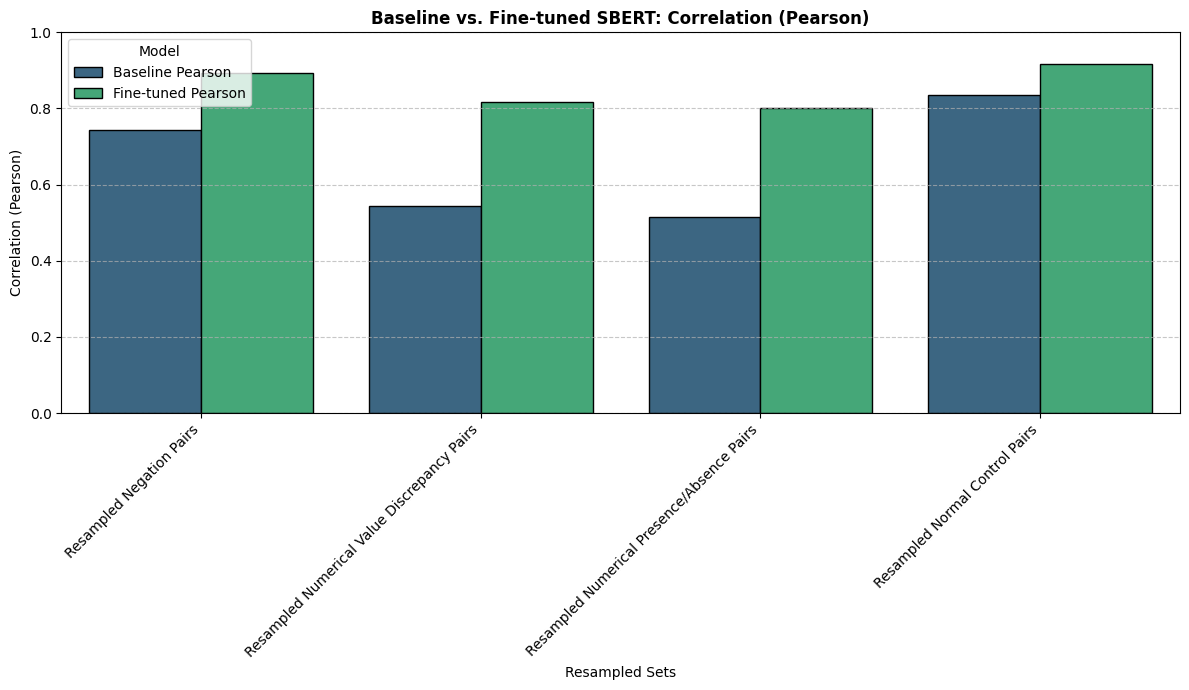

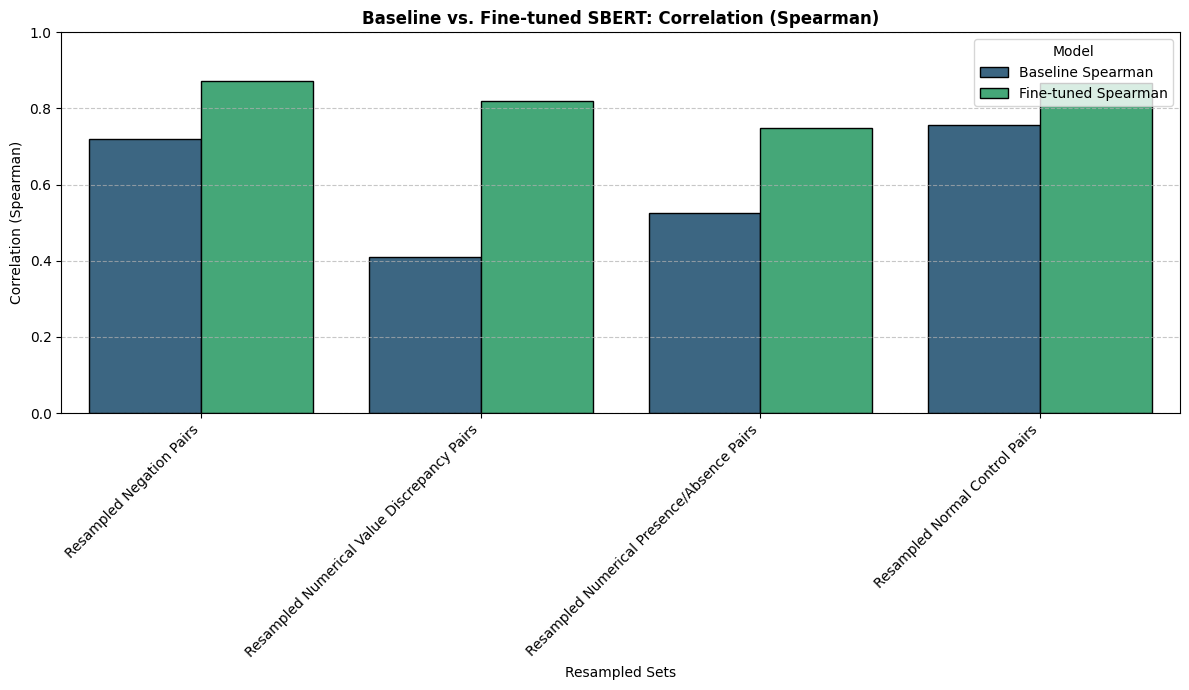

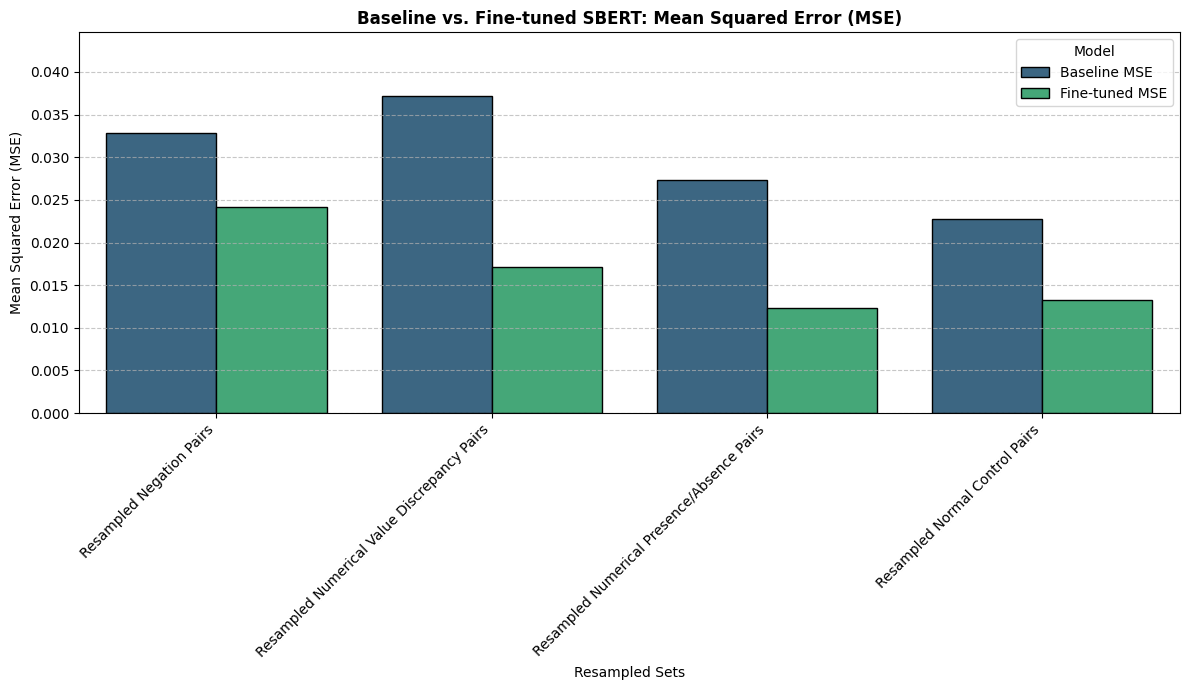

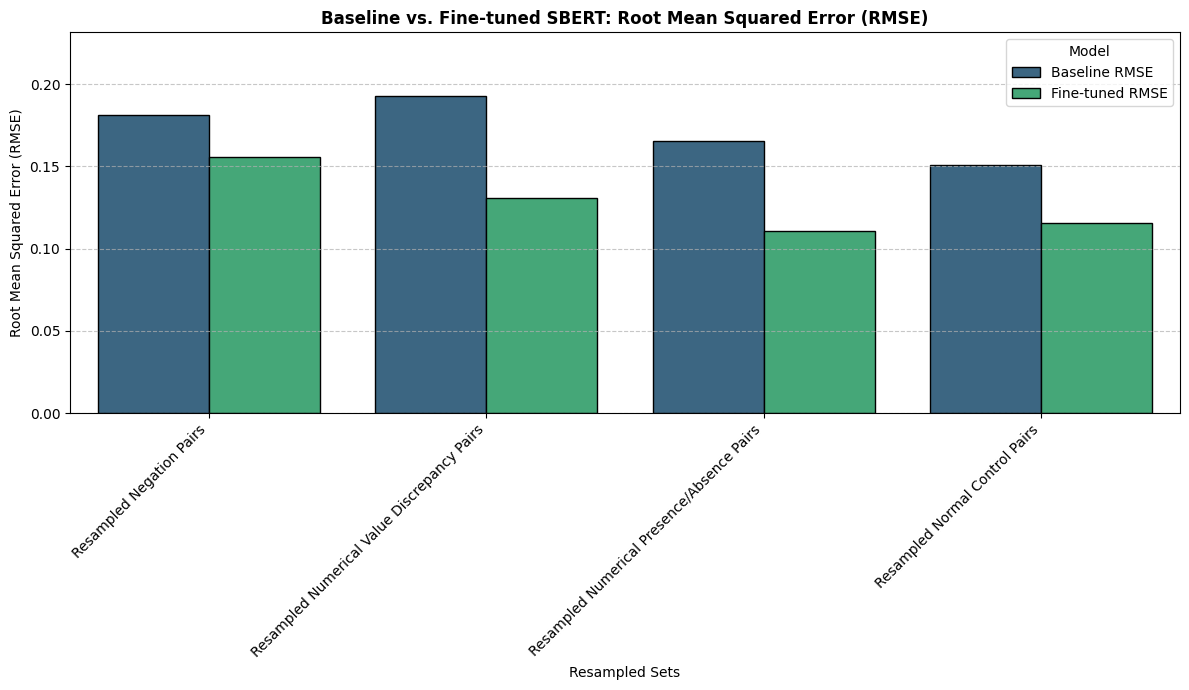


Interpretation: These visualizations clearly demonstrate the impact of fine-tuning on the SBERT model's performance across different linguistic phenomena. We can observe if fine-tuning improved, degraded, or had little effect on each metric for each challenge set compared to the baseline. For correlation metrics (Pearson, Spearman), higher values are better, while for error metrics (MSE, RMSE), lower values are better.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Visualizing Baseline vs. Fine-tuned Performance Comparison across Resampled Sets...")

# Data collected from previous evaluations
performance_data = {
    'Set': [
        'Resampled Negation Pairs',
        'Resampled Numerical Value Discrepancy Pairs',
        'Resampled Numerical Presence/Absence Pairs',
        'Resampled Normal Control Pairs'
    ],
    'Baseline Pearson': [
        0.7437,
        0.5443,
        0.5163,
        0.8366
    ],
    'Fine-tuned Pearson': [
        0.8934,
        0.8163,
        0.8018,
        0.9169
    ],
    'Baseline Spearman': [
        0.7187,
        0.4091,
        0.5259,
        0.7568
    ],
    'Fine-tuned Spearman': [
        0.8725,
        0.8184,
        0.7496,
        0.8670
    ],
    'Baseline MSE': [
        0.0328,
        0.0372,
        0.0273,
        0.0227
    ],
    'Fine-tuned MSE': [
        0.0242,
        0.0171,
        0.0123,
        0.0133
    ],
    'Baseline RMSE': [
        0.1810,
        0.1929,
        0.1652,
        0.1507
    ],
    'Fine-tuned RMSE': [
        0.1557,
        0.1308,
        0.1110,
        0.1155
    ]
}

# Create DataFrame
df_comparison_summary = pd.DataFrame(performance_data)

print("\n--- Summary Table of Baseline vs. Fine-tuned Evaluation Metrics ---")
display(df_comparison_summary)

# --- Plotting comparisons ---

metrics_to_plot = {
    'Correlation (Pearson)': {'baseline_col': 'Baseline Pearson', 'finetuned_col': 'Fine-tuned Pearson', 'ylim': (0, 1), 'is_higher_better': True},
    'Correlation (Spearman)': {'baseline_col': 'Baseline Spearman', 'finetuned_col': 'Fine-tuned Spearman', 'ylim': (0, 1), 'is_higher_better': True},
    'Mean Squared Error (MSE)': {'baseline_col': 'Baseline MSE', 'finetuned_col': 'Fine-tuned MSE', 'ylim': (0, df_comparison_summary[['Baseline MSE', 'Fine-tuned MSE']].max().max() * 1.2), 'is_higher_better': False},
    'Root Mean Squared Error (RMSE)': {'baseline_col': 'Baseline RMSE', 'finetuned_col': 'Fine-tuned RMSE', 'ylim': (0, df_comparison_summary[['Baseline RMSE', 'Fine-tuned RMSE']].max().max() * 1.2), 'is_higher_better': False}
}

for metric_name, cols in metrics_to_plot.items():
    plt.figure(figsize=(12, 7))
    df_plot = df_comparison_summary[['Set', cols['baseline_col'], cols['finetuned_col']]].melt('Set', var_name='Model', value_name=metric_name)
    sns.barplot(x='Set', y=metric_name, hue='Model', data=df_plot, palette='viridis', edgecolor='black')

    plt.title(f'Baseline vs. Fine-tuned SBERT: {metric_name}', fontweight='bold')
    plt.xlabel('Resampled Sets')
    plt.ylabel(metric_name)
    plt.ylim(cols['ylim'])
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()

print("\nInterpretation: These visualizations clearly demonstrate the impact of fine-tuning on the SBERT model's performance across different linguistic phenomena. We can observe if fine-tuning improved, degraded, or had little effect on each metric for each challenge set compared to the baseline. For correlation metrics (Pearson, Spearman), higher values are better, while for error metrics (MSE, RMSE), lower values are better.")